In [ ]:
from google.colab import files

import pandas as pd
import numpy as np
import math
import statsmodels.formula.api as smf
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import (BernoulliNB, ComplementNB,
                                 GaussianNB, MultinomialNB)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             cohen_kappa_score, confusion_matrix, f1_score,
                             ConfusionMatrixDisplay)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from tabulate import tabulate

# Data Exploration & Preprocessing

## Upload individual datasets

In [ ]:
from google.colab import drive
drive.mount ('/content/gdrive')
sold01 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202401_filled.csv")
sold02 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202402_filled.csv")
sold03 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202403_filled.csv")
sold04 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202404_filled.csv")
sold05 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202405_filled.csv")
sold06 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202406_filled.csv")
sold07 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202407_filled.csv")
sold08 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202408.csv")
sold09 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202409.csv")
sold10 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202410.csv")
sold2223 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold20220101_20231231_filled.csv")


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


<ipython-input-67-db1643698b91>:6: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  sold04 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold202404_filled.csv")
<ipython-input-67-db1643698b91>:13: DtypeWarning: Columns (2,36,47,60,63,66,68) have mixed types. Specify dtype option on import or set low_memory=False.
  sold2223 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/data/CRMLSSold20220101_20231231_filled.csv")


In [ ]:
# Load cleaned version
cleaned22 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2022_CRMLS.csv")
cleaned23 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2023_CRMLS.csv")
cleaned24 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2024_CRMLS.csv")

<ipython-input-68-a25a00115dce>:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned22 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2022_CRMLS.csv")
<ipython-input-68-a25a00115dce>:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned23 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2023_CRMLS.csv")
<ipython-input-68-a25a00115dce>:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned24 = pd.read_csv("/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_2024_CRMLS.csv")


### Shape of Each Dataset

In [ ]:
print(sold01.shape)
print(sold02.shape)
print(sold03.shape)
print(sold04.shape)
print(sold05.shape)
print(sold06.shape)
print(sold07.shape)
print(sold08.shape)
print(sold09.shape)
print(sold10.shape)
print(sold2223.shape)

(17958, 80)
(19925, 80)
(23276, 80)
(24640, 80)
(26487, 80)
(24328, 80)
(26240, 80)
(24558, 78)
(21267, 78)
(23274, 78)
(585833, 80)


In [ ]:
print(cleaned22.shape)
print(cleaned23.shape)
print(cleaned24.shape)

(172992, 78)
(125996, 78)
(117708, 77)


### Identify Differences in Columns

In [ ]:
# Identify the two extra columns
extra_columns_in_sold07 = set(sold07.columns) - set(sold08.columns)
extra_columns_in_sold06 = set(sold06.columns) - set(sold09.columns)
extra_columns_in_sold05 = set(sold05.columns) - set(sold10.columns)
print(extra_columns_in_sold07)
print(extra_columns_in_sold06)
print(extra_columns_in_sold05)

{'latfilled', 'lonfilled'}
{'latfilled', 'lonfilled'}
{'latfilled', 'lonfilled'}


In [ ]:
extra_columns_in_sold01 = set(sold01.columns) - set(sold05.columns)
extra_columns_in_sold05 = set(sold05.columns) - set(sold01.columns)
print(extra_columns_in_sold01)
print(extra_columns_in_sold05)

{'BuyerAgencyCompensationType', 'BuyerAgencyCompensation'}
{'BuyerAgentAOR', 'ListAgentAOR'}


In [ ]:
extra_columns_in_cleaned22 = set(cleaned22.columns) - set(cleaned24.columns)
extra_columns_in_cleaned23 = set(cleaned23.columns) - set(cleaned24.columns)
extra_columns_in_cleaned24 = set(cleaned24.columns) - set(cleaned22.columns)
print(extra_columns_in_cleaned22)
print(extra_columns_in_cleaned23)
print(extra_columns_in_cleaned24)

{'Year'}
{'Year'}
set()


## Use only observations with PropertyType="Residential" and PropertySubType="SingleFamilyResidence". Drop unneccessary columns such as BuyerAgencyCompensationType and so on.

In [ ]:
sold_1 = sold01[(sold01["PropertyType"] == "Residential") & (sold01["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_2 = sold02[(sold02["PropertyType"] == "Residential") & (sold02["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_3 = sold03[(sold03["PropertyType"] == "Residential") & (sold03["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_4 = sold04[(sold04["PropertyType"] == "Residential") & (sold04["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_5 = sold05[(sold05["PropertyType"] == "Residential") & (sold05["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_6 = sold06[(sold06["PropertyType"] == "Residential") & (sold06["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_7 = sold07[(sold07["PropertyType"] == "Residential") & (sold07["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_8 = sold08[(sold08["PropertyType"] == "Residential") & (sold08["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_9 = sold09[(sold09["PropertyType"] == "Residential") & (sold09["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_10 = sold10[(sold10["PropertyType"] == "Residential") & (sold10["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')
sold_2223 = sold2223[(sold2223["PropertyType"] == "Residential") & (sold2223["PropertySubType"] == "SingleFamilyResidence")].drop(["BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"], axis=1, errors='ignore')

### df1 combines all previous sales data to predict the future price:

In [ ]:
df1 = combined_df = pd.concat([sold_1, sold_2, sold_3, sold_4, sold_5, sold_6, sold_7, sold_8, sold_9, sold_10, sold_2223], ignore_index=True)

In [ ]:
# Display basic info to get a sense of data types and missing values
print("Basic Info:")
df1.info()

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426327 entries, 0 to 426326
Data columns (total 76 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      273509 non-null  object 
 1   ViewYN                        360623 non-null  object 
 2   WaterfrontYN                  187 non-null     object 
 3   BasementYN                    10289 non-null   object 
 4   PoolPrivateYN                 376449 non-null  object 
 5   OriginalListPrice             425890 non-null  float64
 6   ListingKey                    426327 non-null  int64  
 7   ListAgentEmail                425538 non-null  object 
 8   CloseDate                     426327 non-null  object 
 9   ClosePrice                    426322 non-null  float64
 10  ListAgentFirstName            422108 non-null  object 
 11  ListAgentLastName             426276 non-null  object 
 12  Latitude                      42

In [ ]:
# Only inlcude entries that are CA-located
print(df1['StateOrProvince'].unique())
df1 = df1[df1['StateOrProvince'] == 'CA']
print(df1['StateOrProvince'].unique())
print(df1.shape)

['CA' 'NV' 'AZ' 'TX' 'OS' 'GA' 'ME' 'NY' 'CO' 'MO' 'BC' nan 'AL' 'OR' 'FL'
 'HI' 'ID']
['CA']
(426292, 76)


### df2 combines all cleaned datasets:

In [ ]:
df2 = pd.concat([cleaned22, cleaned23, cleaned24], ignore_index=True)
# Display basic info to get a sense of data types and missing values
print("Basic Info:")
df2.info()

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416696 entries, 0 to 416695
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      416696 non-null  object 
 1   ViewYN                        416696 non-null  object 
 2   WaterfrontYN                  180 non-null     object 
 3   BasementYN                    10049 non-null   object 
 4   PoolPrivateYN                 416696 non-null  object 
 5   OriginalListPrice             416259 non-null  float64
 6   ListingKey                    416696 non-null  int64  
 7   ListAgentEmail                415920 non-null  object 
 8   CloseDate                     416696 non-null  object 
 9   ClosePrice                    416691 non-null  float64
 10  ListAgentFirstName            412528 non-null  object 
 11  ListAgentLastName             416647 non-null  object 
 12  Latitude                      41

In [ ]:
# Only inlcude entries that are CA-located
print(df2['StateOrProvince'].unique())
df2 = df2[df2['StateOrProvince'] == 'CA']
print(df2['StateOrProvince'].unique())
print(df2.shape)

['CA' 'BC' nan 'FL' 'TX' 'HI' 'AZ' 'OS' 'AL' 'NV' 'OR' 'GA' 'ME' 'NY' 'CO'
 'MO']
['CA']
(416664, 78)


In [ ]:
# Drop 'Year' column
#df2 = df2.drop('Year', axis=1)

#### Feature Selection
Property related:
- Location: *'Latitude', 'Longitude'*, 'UnparsedAddress', 'CountyOrParish', 'StreetNumberNumeric', 'City', 'StateOrProvince', 'PostalCode'



- Neighborhood: 'ElementarySchool', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchool', 'HighSchool', 'HighSchoolDistrict’, 'MiddleOrJuniorSchoolDistrict'


- Attributes: 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', *'PropertyType'*, 'LivingArea', 'FireplacesTotal', 'AboveGradeFinishedArea', *'TaxAnnualAmount’*,'AttachedGarageYN', 'ParkingTotal', *'BuilderName', 'PropertySubType'*, 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', *'TaxYear'*, 'BuildingAreaTotal', 'BedroomsTotal', 'BelowGradeFinishedArea', 'CoveredSpaces’,'FireplaceYN', 'Stories', 'Levels', 'LotSizeDimensions', 'LotSizeArea','MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'LotSizeSquareFeet'



Listing related / Uncertain:
    'OriginalListPrice', 'ListingKey', 'ListAgentEmail', **'CloseDate'**,
    **'ClosePrice',** 'ListAgentFirstName', 'ListAgentLastName', ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName','CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName','CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName','BuyerAgentLastName’, 'AssociationFeeFrequency', *'MLSAreaMajor', 'MlsStatus’*, ‘SubdivisionName’, 'BuyerOfficeAOR’, 'ListingId','ContractStatusChangeDate’, 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'ListingContractDate', 'BusinessType', 'AssociationFee', "BuyerAgencyCompensationType", "BuyerAgencyCompensation", "latfilled", "lonfilled", "BuyerAgentAOR", "ListAgentAOR"


In [ ]:
# Define the list of property-related columns to keep
property_related_columns = [
    'Latitude', 'Longitude', 'UnparsedAddress', 'CountyOrParish', 'StreetNumberNumeric', 'City', 'PostalCode',
    'ElementarySchool', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchool', 'HighSchool',
    'HighSchoolDistrict', 'MiddleOrJuniorSchoolDistrict',
    'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'LivingArea',
    'FireplacesTotal', 'AboveGradeFinishedArea', 'AttachedGarageYN', 'ParkingTotal',
    'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BuildingAreaTotal', 'BedroomsTotal',
    'BelowGradeFinishedArea', 'CoveredSpaces', 'FireplaceYN', 'Stories', 'Levels',
    'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
    'LotSizeSquareFeet'
]

useful_listing_related_columns = ['CloseDate', 'ClosePrice']

# Filter df1 to keep only the specified property-related columns
df = df1[property_related_columns+useful_listing_related_columns]
print(df.shape)

# Set display option to show more columns
pd.set_option('display.max_columns', None)
# Display the resulting dataframe to verify the columns
df.head()


(426292, 41)


,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,ElementarySchool,ElementarySchoolDistrict,MiddleOrJuniorSchool,HighSchool,HighSchoolDistrict,MiddleOrJuniorSchoolDistrict,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,FireplacesTotal,AboveGradeFinishedArea,AttachedGarageYN,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,CoveredSpaces,FireplaceYN,Stories,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice
0,32.659315,-117.096922,2811 C Avenue,San Diego,2811.0,National City,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,1974.0,NaN,NaN,True,2.0,NaN,2023.0,4.0,NaN,4.0,NaN,NaN,False,2.0,Two,NaN,NaN,NaN,False,2.0,NaN,2024-01-05,815000.0
1,32.659284,-117.097174,2812 C Avenue,San Diego,2812.0,National City,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,1974.0,NaN,NaN,True,2.0,NaN,2023.0,4.0,NaN,4.0,NaN,NaN,False,2.0,Two,NaN,NaN,NaN,False,2.0,NaN,2024-01-05,810000.0
2,35.277199,-120.646786,2054 Fixlini Street,San Luis Obispo,2054.0,San Luis Obispo,93401,NaN,NaN,NaN,NaN,San Luis Coastal Unified,NaN,NaN,True,NaN,NaN,False,3736.0,NaN,NaN,True,3.0,0.2576,2019.0,4.0,NaN,4.0,NaN,NaN,True,2.0,Two,NaN,11219.00,3.0,False,3.0,11219.0,2024-01-02,2100000.0
3,39.419080,-123.814842,31451 Bay View Avenue,Mendocino,31451.0,Fort Bragg,95437,NaN,NaN,NaN,NaN,NaN,NaN,Tile,True,NaN,NaN,False,2100.0,NaN,NaN,True,2.0,1.7100,1986.0,0.0,NaN,3.0,NaN,NaN,True,2.0,Two,NaN,1.71,NaN,NaN,2.0,74487.6,2024-01-22,1950000.0
4,37.325454,-121.780303,3114 Rasmus Circle,Santa Clara,3114.0,San Jose,95148,Other,NaN,Other,Other,Other,NaN,"Tile,Wood",True,NaN,NaN,NaN,2442.0,NaN,NaN,True,3.0,0.2000,1985.0,3.0,NaN,4.0,NaN,NaN,True,NaN,NaN,NaN,8712.00,NaN,False,3.0,8712.0,2024-01-31,2340000.0


In [ ]:
df.dtypes

,0
Latitude,float64
Longitude,float64
UnparsedAddress,object
CountyOrParish,object
StreetNumberNumeric,float64
City,object
PostalCode,object
ElementarySchool,object
ElementarySchoolDistrict,float64
MiddleOrJuniorSchool,object


In [ ]:
# on cleaned version
df_clean = df2[property_related_columns+useful_listing_related_columns]
print(df_clean.shape)

# Set display option to show more columns
pd.set_option('display.max_columns', None)
# Display the resulting dataframe to verify the columns
df_clean.head()

(416664, 41)


,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,ElementarySchool,ElementarySchoolDistrict,MiddleOrJuniorSchool,HighSchool,HighSchoolDistrict,MiddleOrJuniorSchoolDistrict,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,FireplacesTotal,AboveGradeFinishedArea,AttachedGarageYN,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,CoveredSpaces,FireplaceYN,Stories,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice
0,33.147270,-117.340604,295 Chinquapin Ave,San Diego,295.0,Carlsbad,92008.0,NaN,NaN,NaN,NaN,Carlsbad Unified,NaN,"Carpet, Tile, Wood",True,NaN,NaN,False,2645.0,NaN,NaN,True,2.0,0.3071,2016.0,4.0,NaN,4.0,NaN,NaN,False,1.358446,ThreeOrMore,NaN,13376.0,0.000000,NaN,2.0,13376.0,2022-01-04,2499999.0
1,34.235979,-117.202269,944 Mecham Drive,San Bernardino,944.0,Lake Arrowhead,92352.0,NaN,NaN,NaN,NaN,Rim of the World,NaN,"Carpet, Tile",True,NaN,NaN,False,2070.0,NaN,NaN,True,1.0,0.0780,2007.0,3.0,NaN,3.0,NaN,NaN,True,1.358446,ThreeOrMore,NaN,3397.0,0.000000,False,1.0,3397.0,2022-01-10,640000.0
2,34.114130,-117.442493,16596 Miller Avenue,San Bernardino,16596.0,Fontana,92336.0,NaN,NaN,NaN,NaN,Fontana Unified,NaN,"Carpet, Tile",False,NaN,NaN,False,1174.0,NaN,NaN,True,2.0,0.2273,1960.0,2.0,NaN,3.0,NaN,NaN,False,1.000000,One,NaN,9900.0,3.000000,False,2.0,9900.0,2022-03-23,438000.0
3,33.783767,-116.447280,36353 Paseo Del Sol,Riverside,36353.0,Cathedral City,92234.0,NaN,NaN,NaN,NaN,NaN,NaN,"Carpet,Tile",True,NaN,NaN,True,1996.0,NaN,NaN,False,4.0,0.1400,2005.0,2.0,NaN,2.0,NaN,NaN,True,1.358446,Unknown,NaN,6098.0,2.295302,NaN,2.0,6098.0,2022-01-10,615000.0
4,39.767729,-121.586400,6091 Vista Knolls Drive,Butte,6091.0,Paradise,95969.0,NaN,NaN,NaN,NaN,Paradise Unified,NaN,"Carpet, Tile",True,NaN,NaN,False,1422.0,NaN,NaN,True,2.0,0.2800,2021.0,2.0,NaN,3.0,NaN,NaN,False,1.000000,One,NaN,12197.0,3.000000,True,2.0,12197.0,2022-01-19,399990.0


#### Count Missing Values

In [ ]:
# Check for missing values in each column
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
Latitude                           317
Longitude                          317
UnparsedAddress                   9919
CountyOrParish                       0
StreetNumberNumeric              10027
City                              2212
PostalCode                           2
ElementarySchool                365562
ElementarySchoolDistrict        426292
MiddleOrJuniorSchool            364311
HighSchool                      348235
HighSchoolDistrict              109423
MiddleOrJuniorSchoolDistrict    426292
Flooring                        152805
ViewYN                           65702
WaterfrontYN                    426105
BasementYN                      416008
PoolPrivateYN                    49878
LivingArea                         273
FireplacesTotal                 426292
AboveGradeFinishedArea          426292
AttachedGarageYN                 46985
ParkingTotal                      8325
LotSizeAcres                      7623
YearBuilt                          399
Ba

In [ ]:
# Drop rows with missing values in 'ClosePrice' column
df = df.dropna(subset=['ClosePrice'])
df.shape

(426287, 41)

In [ ]:
# Drop columns where all values are missing
df = df.dropna(axis=1, how='all')

In [ ]:
df.shape

(426287, 36)

In [ ]:
# on cleaned version
# Check for missing values in each column
print("\nMissing Values Count:")
print(df_clean.isnull().sum())


Missing Values Count:
Latitude                           317
Longitude                          317
UnparsedAddress                   9913
CountyOrParish                       0
StreetNumberNumeric              10019
City                                 0
PostalCode                           2
ElementarySchool                357262
ElementarySchoolDistrict        416664
MiddleOrJuniorSchool            356066
HighSchool                      340431
HighSchoolDistrict              107562
MiddleOrJuniorSchoolDistrict    416664
Flooring                             0
ViewYN                               0
WaterfrontYN                    416484
BasementYN                      406619
PoolPrivateYN                        0
LivingArea                           0
FireplacesTotal                 416664
AboveGradeFinishedArea          416664
AttachedGarageYN                 45748
ParkingTotal                      8317
LotSizeAcres                      7489
YearBuilt                          382
Ba

In [ ]:
# Drop rows with missing values in 'ClosePrice' column
df_clean = df_clean.dropna(subset=['ClosePrice'])
df_clean.shape

(416659, 41)

In [ ]:
# Drop columns where all values are missing
df_clean = df_clean.dropna(axis=1, how='all')
df_clean.shape

(416659, 36)

#### Initial Correlation Matrix

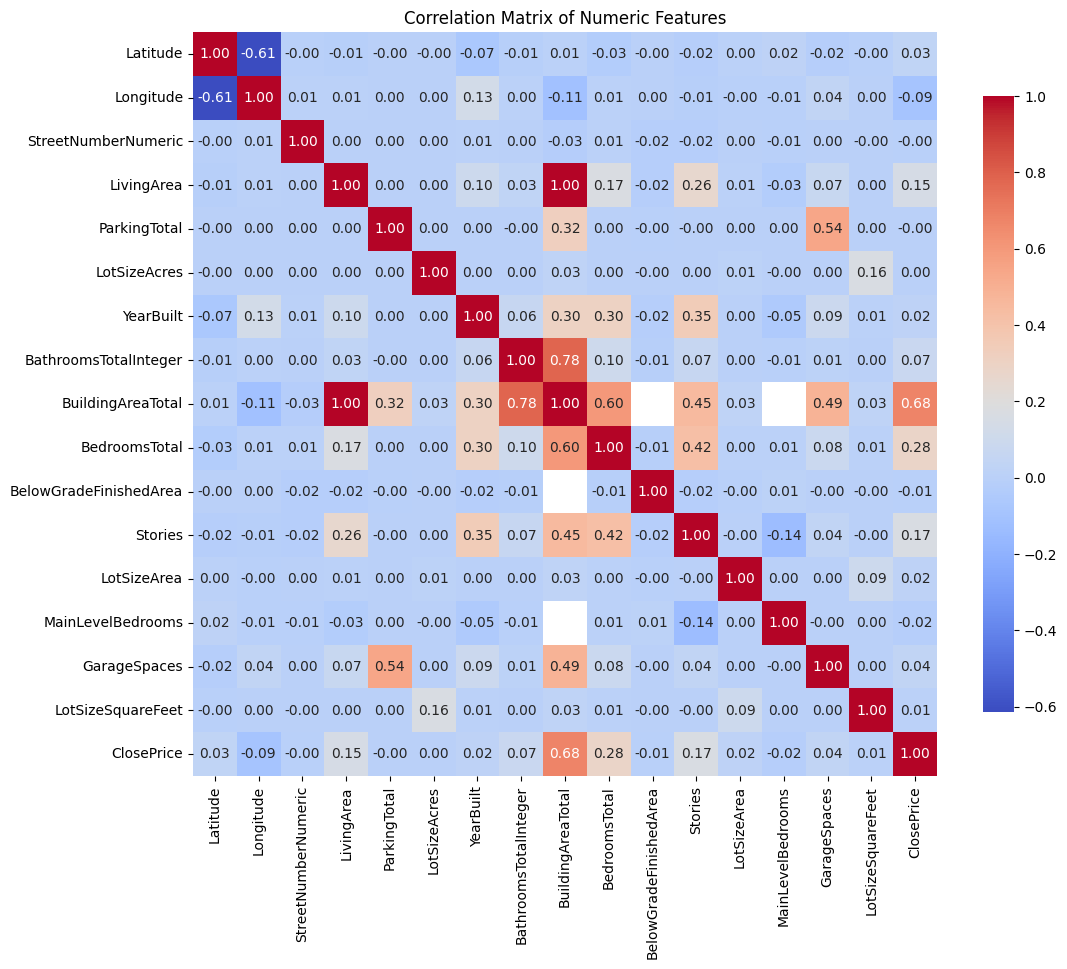

In [ ]:
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Numeric Features")
plt.show()

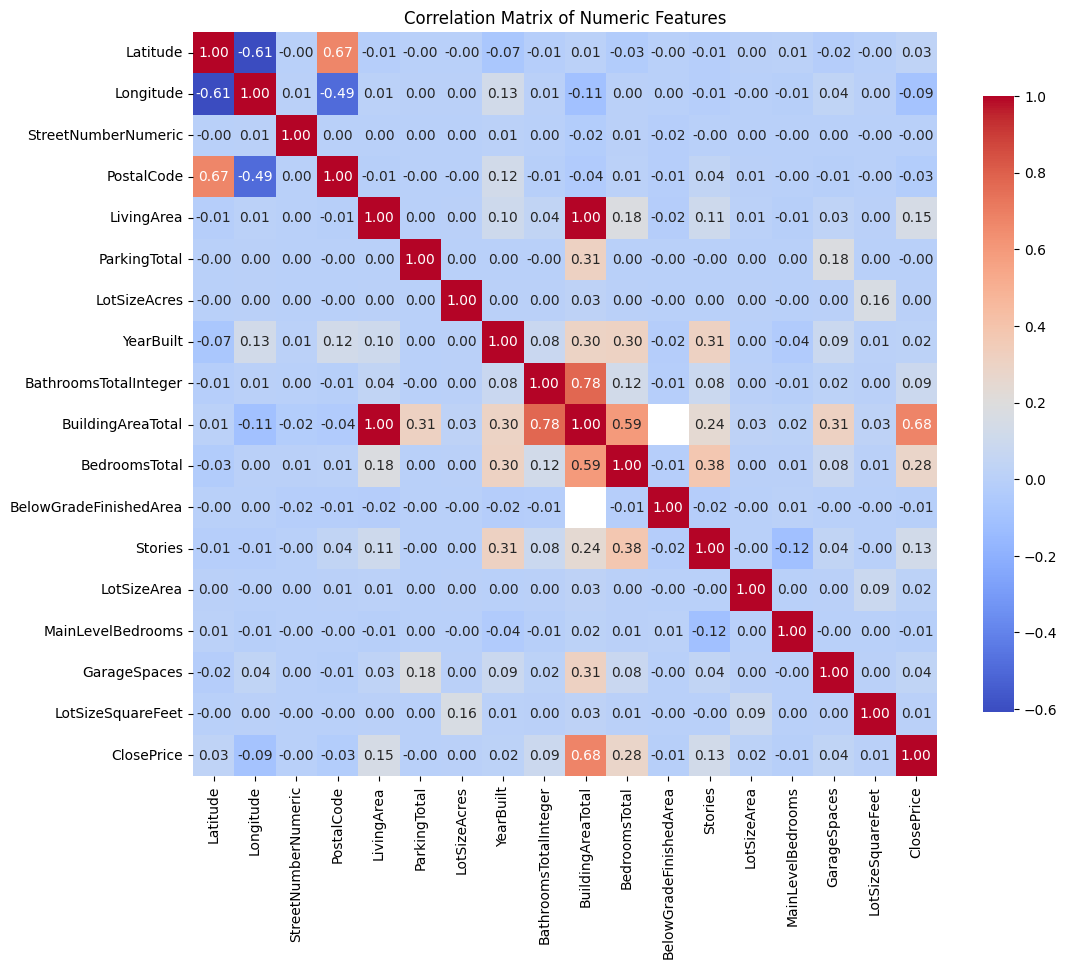

In [ ]:
# correlation matrix on cleaned version
# Select only numeric columns for correlation matrix
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Numeric Features")
plt.show()


In [ ]:
# Delete Highly Correlated Features
df = df.drop('BuildingAreaTotal', axis=1)
df_clean = df_clean.drop('BuildingAreaTotal', axis=1)

#### Lot-related Features Investigation

In [ ]:
# Identify columns that start with 'Lot'
lot_columns = [col for col in df.columns if col.startswith('Lot')]
lot_columns

['LotSizeAcres', 'LotSizeDimensions', 'LotSizeArea', 'LotSizeSquareFeet']

In [ ]:
pd.set_option('display.max_rows', None)
# Display first few rows with only the 'Lot' columns
df[lot_columns].head(100)

,LotSizeAcres,LotSizeDimensions,LotSizeArea,LotSizeSquareFeet
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,0.2576,NaN,11219.00,11219.0
3,1.7100,NaN,1.71,74487.6
4,0.2000,NaN,8712.00,8712.0
5,0.2991,47x282,13029.00,13029.0
6,0.1599,NaN,6966.00,6966.0
7,0.1148,NaN,5000.00,5000.0
8,0.2238,NaN,9750.00,9750.0
9,NaN,NaN,NaN,NaN


1 acre = 43560 square feet

In [ ]:
# Also, LotSizeSquareFeet has less missing values
df = df.drop(columns=['LotSizeAcres', 'LotSizeDimensions', 'LotSizeArea'])
df_clean = df_clean.drop(columns=['LotSizeAcres', 'LotSizeDimensions', 'LotSizeArea'])

#### ParkingTotal and GarageSpaces Investigation
Missing Value Count:
- ParkingTotal 346
- GarageSpaces 3614

In [ ]:
df[['ParkingTotal','GarageSpaces']].head(100)

,ParkingTotal,GarageSpaces
0,2.0,2.0
1,2.0,2.0
2,3.0,3.0
3,2.0,2.0
4,3.0,3.0
5,2.0,NaN
6,2.0,2.0
7,1.0,1.0
8,3.0,3.0
9,4.0,2.0


In [ ]:
df[['ParkingTotal','GarageSpaces']].describe()

,ParkingTotal,GarageSpaces
count,417962.000000,411773.000000
mean,3.419048,2.006800
std,298.511115,4.093534
min,-139.000000,0.000000
25%,2.000000,2.000000
50%,2.000000,2.000000
75%,3.000000,2.000000
max,192312.000000,600.000000


In [ ]:
# Drop rows where 'ParkingTotal' is less than 0
df = df[df['ParkingTotal'] >= 0]
df_clean = df_clean[df_clean['ParkingTotal'] >= 0]

In [ ]:
print(df.shape)
print(df_clean.shape)

(417869, 32)
(408249, 32)


#### Feature Engineering

##### School District
- ElementarySchool                 90093
- MiddleOrJuniorSchool             89936
- HighSchool                       85567
- HighSchoolDistrict               26347

In [ ]:
# Define the columns of interest
school_columns = [
    'ElementarySchool',
    'MiddleOrJuniorSchool',
    'HighSchool',
    'HighSchoolDistrict'
]

# Display the first few rows with only the specified school-related columns
df[school_columns].head(100)


,ElementarySchool,MiddleOrJuniorSchool,HighSchool,HighSchoolDistrict
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,San Luis Coastal Unified
3,NaN,NaN,NaN,NaN
4,Other,Other,Other,Other
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,Other
7,NaN,NaN,NaN,Other
8,NaN,NaN,NaN,Saddleback Valley Unified
9,NaN,NaN,NaN,NaN


In [ ]:
# Display unique values in the 'HighSchoolDistrict' column
print(df['HighSchoolDistrict'].unique())

# Count the number of unique values in the 'HighSchoolDistrict' column
unique_high_school_districts_count = df['HighSchoolDistrict'].nunique()
unique_high_school_districts_count


[nan 'San Luis Coastal Unified' 'Other' 'Saddleback Valley Unified'
 'William S. Hart Union' 'Fallbrook Union' 'Torrance Unified'
 'Alpine Union' 'West Covina' 'Manhattan Unified' 'Los Angeles Unified'
 'Paramount Unified' 'Capistrano Unified' 'Carlsbad Unified'
 'San Jose Unified' 'Huntington Beach Union High' 'Newport Mesa Unified'
 'Rim of the World' 'Oceanside Unified' 'Santa Monica-Malibu Unified'
 'Orland Joint Unified' 'Santa Maria Joint Union' 'Norwalk - La Mirada'
 'Palo Alto Unified' 'Grossmont Union' 'Hayward' 'Oakland'
 'Temecula Unified' 'El Segundo Unified' 'Charter Oak Unified'
 'Tustin Unified' 'Las Virgenes' 'Fremont Unified' 'Conejo Valley Unified'
 'Redlands Unified' 'Pomona Unified' 'Vista Unified' 'Hesperia Unified'
 'Merced City' 'Westside Union' 'Jurupa Unified' 'Anaheim Union High'
 'Lakeside Union' 'Palm Springs Unified' 'Long Beach Unified'
 'Hacienda La Puente Unified' 'Yucaipa/Calimesa Unified'
 'Placentia-Yorba Linda Unified' 'Lancaster' 'Irvine Unified'
 '

448

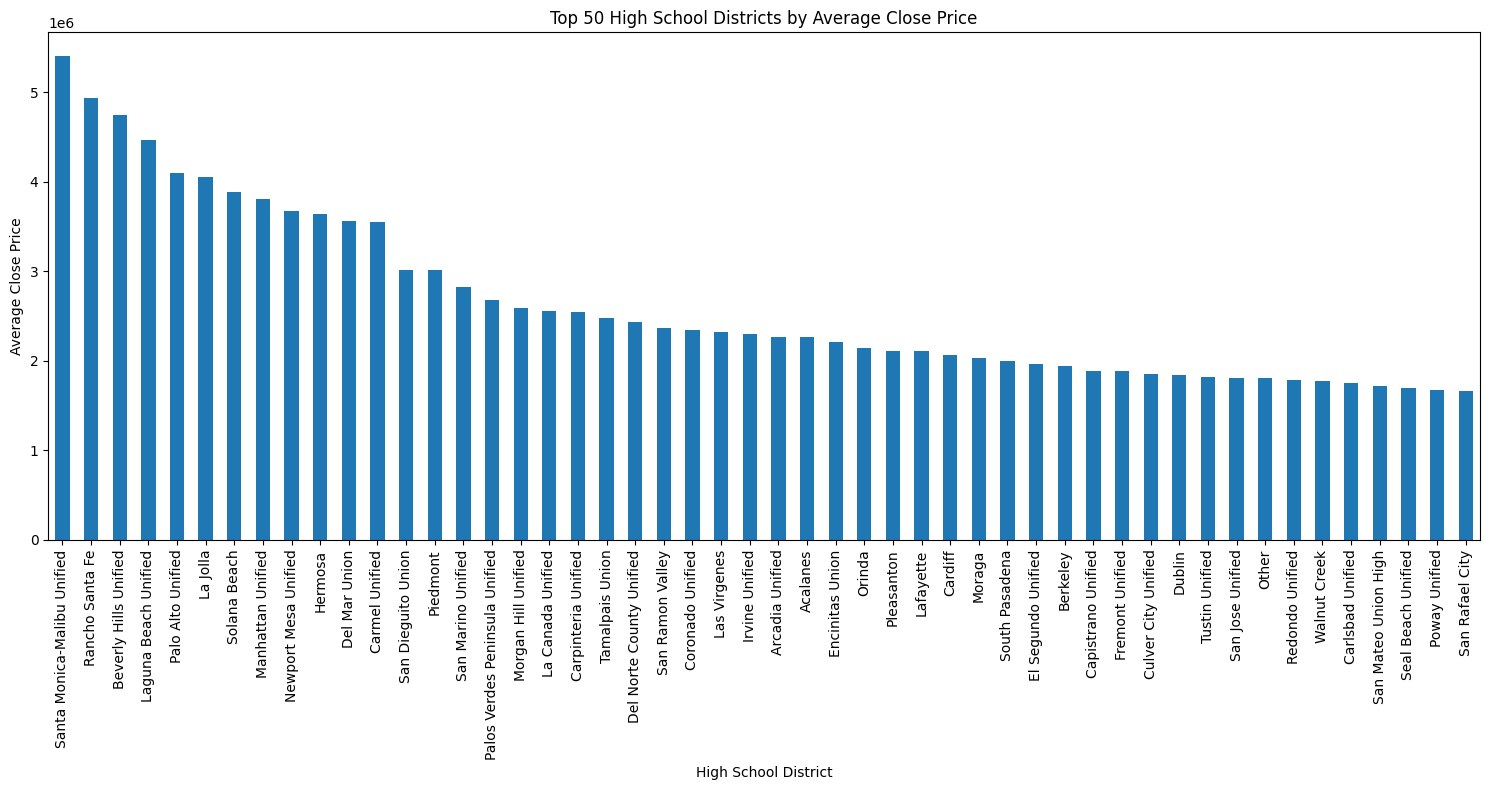

In [ ]:
# Group by 'HighSchoolDistrict' and calculate the average 'ClosePrice' for each district
top_50_districts = (
    df.groupby('HighSchoolDistrict')['ClosePrice']
    .mean()
    .sort_values(ascending=False)
    .head(50)
)

# Plotting the top 50 HighSchoolDistricts with the highest average ClosePrice
plt.figure(figsize=(15, 8))
top_50_districts.plot(kind='bar', fontsize=10)
plt.title("Top 50 High School Districts by Average Close Price")
plt.xlabel("High School District")
plt.ylabel("Average Close Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# Get the list of top 50 districts by average close price
top_50_districts_list = top_50_districts.index

# Create the binary column 'ExpensiveSchoolDistrictYN'
df['ExpensiveSchoolDistrictYN'] = df['HighSchoolDistrict'].isin(top_50_districts_list).astype(int)


In [ ]:
# Drop Unnecessary Columns
df = df.drop(columns=school_columns)

In [ ]:
df.shape

(417869, 29)

In [ ]:
# on cleaned version
# Count the number of unique values in the 'HighSchoolDistrict' column
unique_high_school_districts_count = df_clean['HighSchoolDistrict'].nunique()
unique_high_school_districts_count

448

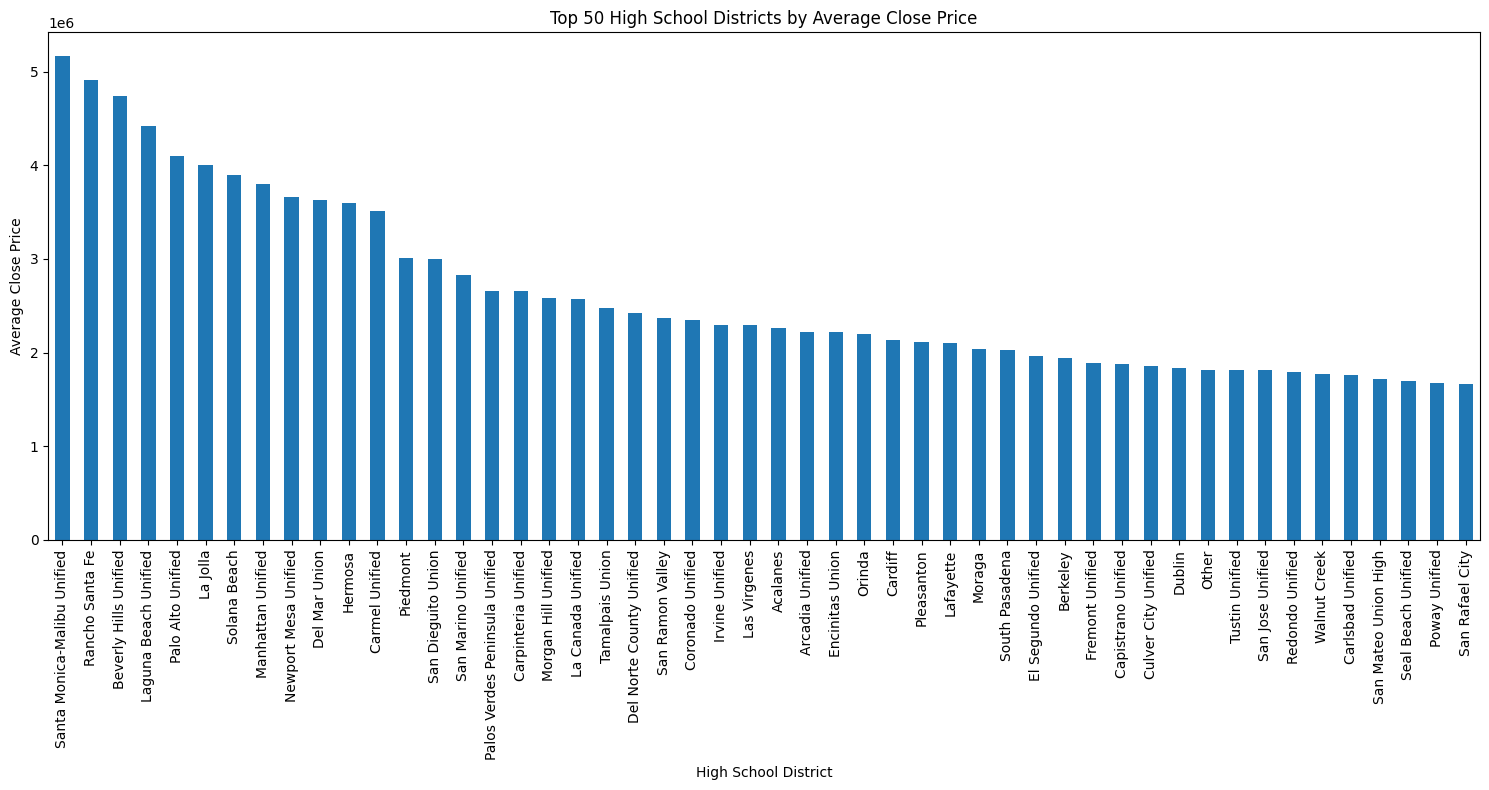

(408249, 29)


In [ ]:
# Group by 'HighSchoolDistrict' and calculate the average 'ClosePrice' for each district
top_50_districts = (
    df_clean.groupby('HighSchoolDistrict')['ClosePrice']
    .mean()
    .sort_values(ascending=False)
    .head(50)
)

# Plotting the top 50 HighSchoolDistricts with the highest average ClosePrice
plt.figure(figsize=(15, 8))
top_50_districts.plot(kind='bar', fontsize=10)
plt.title("Top 50 High School Districts by Average Close Price")
plt.xlabel("High School District")
plt.ylabel("Average Close Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Get the list of top 50 districts by average close price
top_50_districts_list = top_50_districts.index

# Create the binary column 'ExpensiveSchoolDistrictYN'
df_clean['ExpensiveSchoolDistrictYN'] = df_clean['HighSchoolDistrict'].isin(top_50_districts_list).astype(int)

# Drop Unnecessary Columns
df_clean = df_clean.drop(columns=school_columns)
print(df_clean.shape)

##### Additional Attractions

In [ ]:
# Identify columns that end with 'YN' excluding 'ExpensiveSchoolDistrictYN'
yn_columns = [col for col in df.columns if col.endswith('YN') and col != 'ExpensiveSchoolDistrictYN']
yn_columns


['ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'FireplaceYN',
 'NewConstructionYN']

In [ ]:
df[yn_columns].head(10)

,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,AttachedGarageYN,FireplaceYN,NewConstructionYN
0,False,NaN,NaN,False,True,False,False
1,False,NaN,NaN,False,True,False,False
2,True,NaN,NaN,False,True,True,False
3,True,NaN,NaN,False,True,True,NaN
4,True,NaN,NaN,NaN,True,True,False
5,True,NaN,NaN,False,True,True,False
6,False,NaN,NaN,NaN,True,True,False
7,False,NaN,NaN,NaN,True,True,False
8,True,NaN,NaN,True,True,True,False
9,True,NaN,NaN,False,False,True,False


In [ ]:
# Convert True/False to 1/0 and set missing values to 0 in yn_columns
df[yn_columns] = df[yn_columns].fillna(False).astype(int)

# Create a new column 'AdditionalAttractions' that sums the values in yn_columns
df['AdditionalAttractions'] = df[yn_columns].sum(axis=1)

# Display the first few rows to verify the changes
df[yn_columns + ['AdditionalAttractions']].head()


<ipython-input-111-2c2ecbc58ae6>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yn_columns] = df[yn_columns].fillna(False).astype(int)


,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,AttachedGarageYN,FireplaceYN,NewConstructionYN,AdditionalAttractions
0,0,0,0,0,1,0,0,1
1,0,0,0,0,1,0,0,1
2,1,0,0,0,1,1,0,3
3,1,0,0,0,1,1,0,3
4,1,0,0,0,1,1,0,3


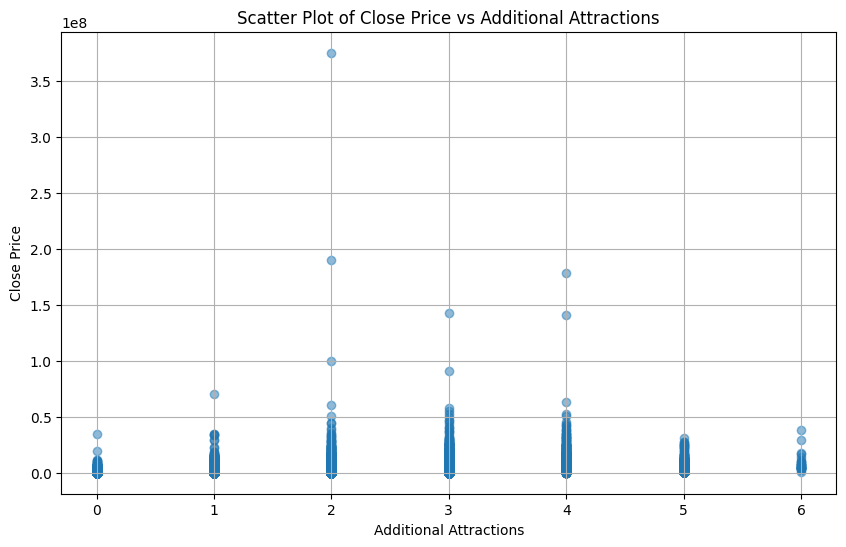

In [ ]:
# Plot a scatter plot of 'ClosePrice' vs 'AdditionalAttractions'
plt.figure(figsize=(10, 6))
plt.scatter(df['AdditionalAttractions'], df['ClosePrice'], alpha=0.5)
plt.title("Scatter Plot of Close Price vs Additional Attractions")
plt.xlabel("Additional Attractions")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()


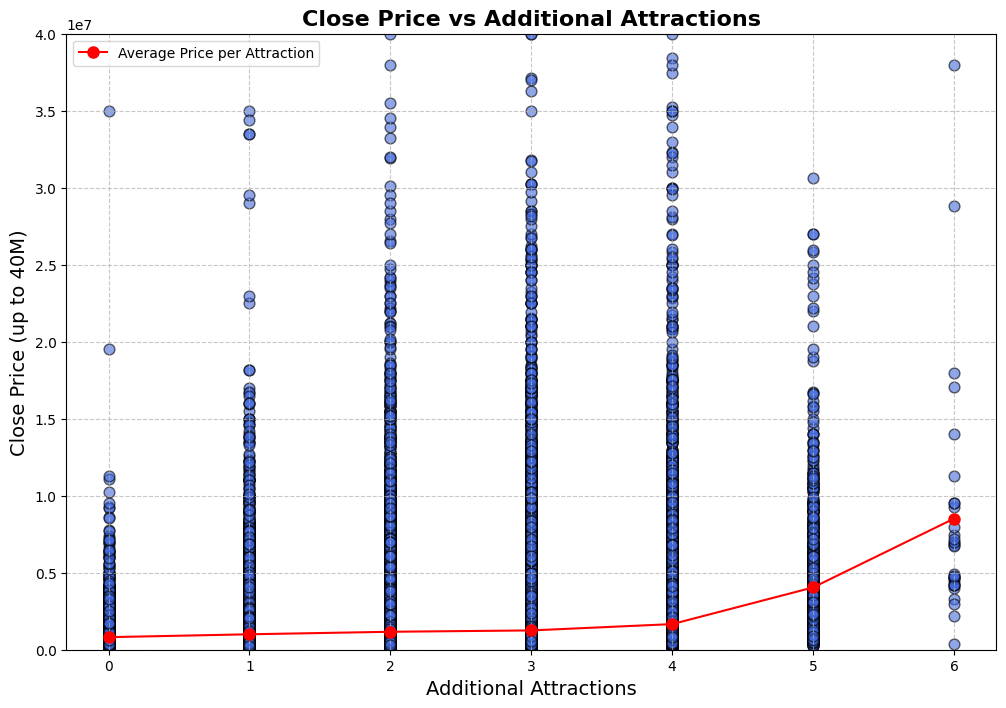

In [ ]:
# Calculate the average ClosePrice for each level of AdditionalAttractions
average_price_per_attraction = df.groupby('AdditionalAttractions')['ClosePrice'].mean()

# Plotting the refined scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df['AdditionalAttractions'], df['ClosePrice'], alpha=0.6, c='royalblue', edgecolor='k', s=60)

# Set the y-axis limit to focus on the range 0 - 4e7
plt.ylim(0, 4e7)

# Plotting the average price point for each group of AdditionalAttractions
plt.plot(average_price_per_attraction.index, average_price_per_attraction.values,
         color='red', marker='o', markersize=8, linestyle='-', label='Average Price per Attraction')

# Adding titles, labels, and legend
plt.title("Close Price vs Additional Attractions", fontsize=16, fontweight='bold')
plt.xlabel("Additional Attractions", fontsize=14)
plt.ylabel("Close Price (up to 40M)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show tick labels in scientific notation for better readability
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()


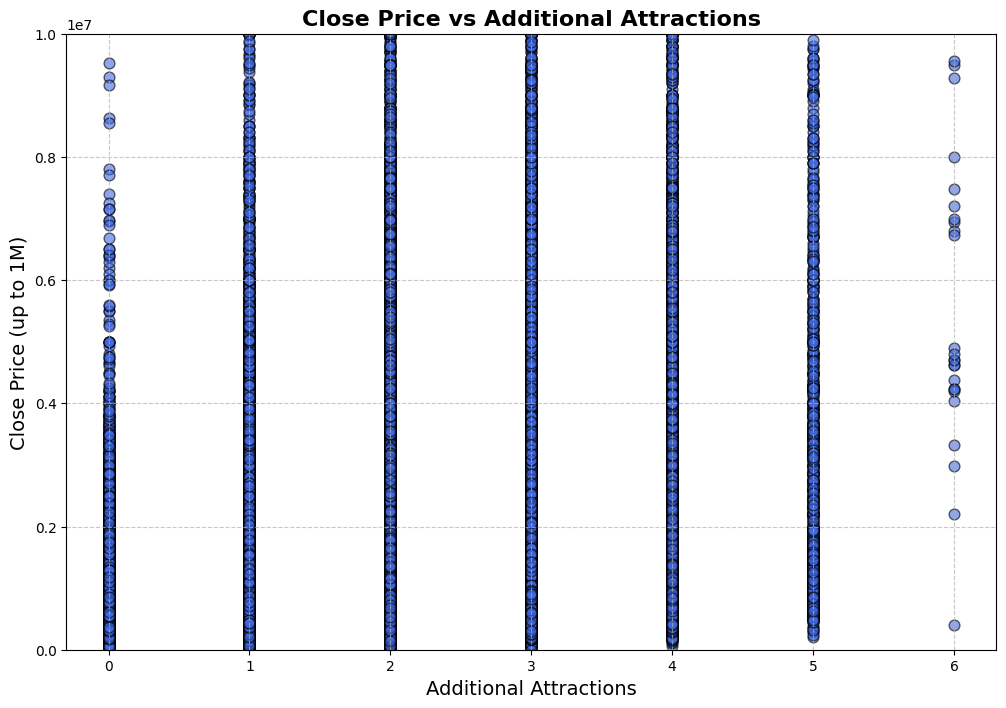

In [ ]:
# Plot a refined scatter plot with more details
plt.figure(figsize=(12, 8))
plt.scatter(df['AdditionalAttractions'], df['ClosePrice'], alpha=0.6, c='royalblue', edgecolor='k', s=60)

# Set the y-axis limit to focus on the range
plt.ylim(0, 1e7)

# Adding titles and labels with more refined formatting
plt.title("Close Price vs Additional Attractions", fontsize=16, fontweight='bold')
plt.xlabel("Additional Attractions", fontsize=14)
plt.ylabel("Close Price (up to 1M)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Show tick labels in scientific notation for better readability
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()


In [ ]:
df.drop(columns=yn_columns, inplace=True)

In [ ]:
df.shape

(417869, 23)

In [ ]:
# on cleaned version
df_clean[yn_columns].head(20)

,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,AttachedGarageYN,FireplaceYN,NewConstructionYN
0,True,NaN,NaN,False,True,False,NaN
1,True,NaN,NaN,False,True,True,False
2,False,NaN,NaN,False,True,False,False
3,True,NaN,NaN,True,False,True,NaN
4,True,NaN,NaN,False,True,False,True
5,True,NaN,NaN,False,False,True,False
6,False,NaN,NaN,False,True,True,NaN
7,True,NaN,NaN,False,True,True,NaN
8,False,NaN,NaN,False,NaN,NaN,False
9,False,NaN,NaN,False,True,True,False


In [ ]:
# Convert 'True'/'False' strings to Boolean, 'missing' to False, and fill NaNs with False
df_clean[yn_columns] = df_clean[yn_columns].replace({'True': True, 'False': False, 'Missing': False}).fillna(False).astype(int)

# Create a new column 'AdditionalAttractions' that sums the values in yn_columns
df_clean['AdditionalAttractions'] = df_clean[yn_columns].sum(axis=1)

# Display the first few rows to verify the changes
df_clean[yn_columns + ['AdditionalAttractions']].head()


<ipython-input-118-e91dc7601aec>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[yn_columns] = df_clean[yn_columns].replace({'True': True, 'False': False, 'Missing': False}).fillna(False).astype(int)
<ipython-input-118-e91dc7601aec>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[yn_columns] = df_clean[yn_columns].replace({'True': True, 'False': False, 'Missing': False}).fillna(False).astype(int)


,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,AttachedGarageYN,FireplaceYN,NewConstructionYN,AdditionalAttractions
0,1,0,0,0,1,0,0,2
1,1,0,0,0,1,1,0,3
2,0,0,0,0,1,0,0,1
3,1,0,0,1,0,1,0,3
4,1,0,0,0,1,0,1,3


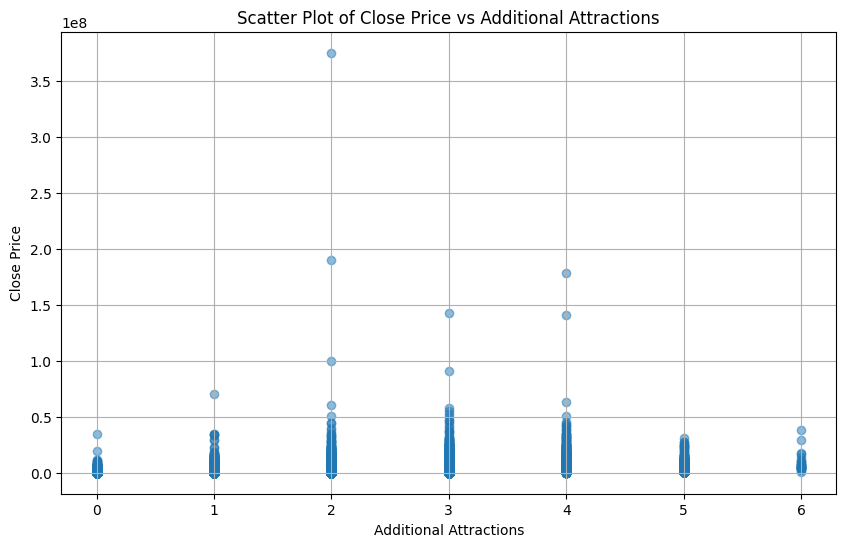

In [ ]:
# Plot a scatter plot of 'ClosePrice' vs 'AdditionalAttractions'
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['AdditionalAttractions'], df_clean['ClosePrice'], alpha=0.5)
plt.title("Scatter Plot of Close Price vs Additional Attractions")
plt.xlabel("Additional Attractions")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()


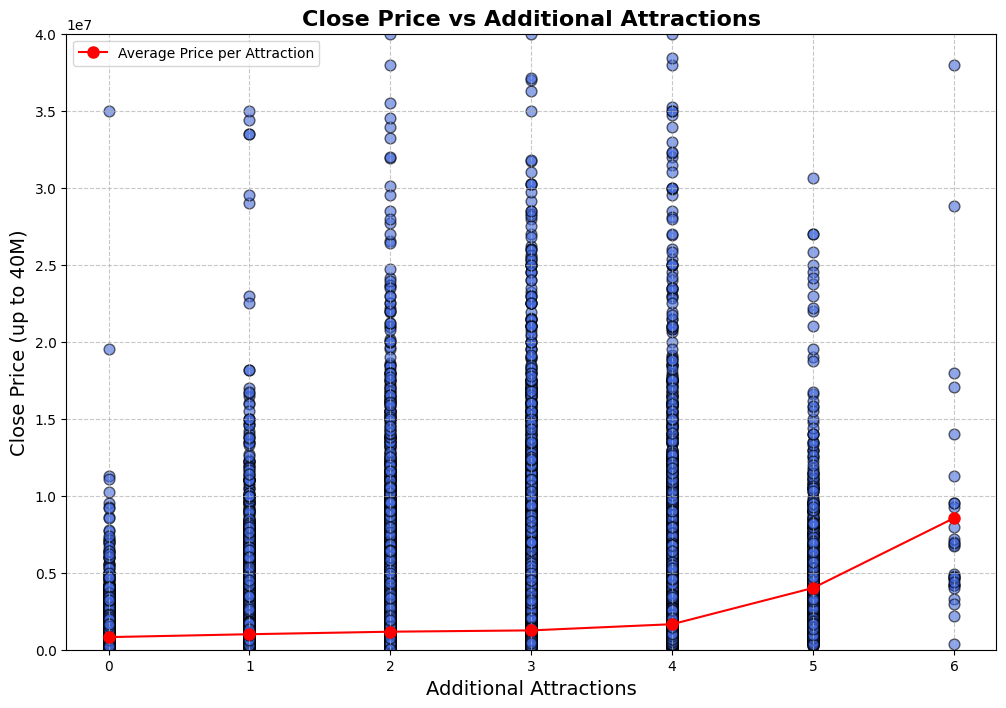

In [ ]:
# Calculate the average ClosePrice for each level of AdditionalAttractions
average_price_per_attraction = df_clean.groupby('AdditionalAttractions')['ClosePrice'].mean()

# Plotting the refined scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['AdditionalAttractions'], df_clean['ClosePrice'], alpha=0.6, c='royalblue', edgecolor='k', s=60)

# Set the y-axis limit to focus on the range 0 - 4e7
plt.ylim(0, 4e7)

# Plotting the average price point for each group of AdditionalAttractions
plt.plot(average_price_per_attraction.index, average_price_per_attraction.values,
         color='red', marker='o', markersize=8, linestyle='-', label='Average Price per Attraction')

# Adding titles, labels, and legend
plt.title("Close Price vs Additional Attractions", fontsize=16, fontweight='bold')
plt.xlabel("Additional Attractions", fontsize=14)
plt.ylabel("Close Price (up to 40M)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show tick labels in scientific notation for better readability
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()

In [ ]:
#df_clean.drop(columns=yn_columns, inplace=True)
df_clean.shape

(408249, 30)

##### Building Age
This would be more helpful if we include sales data of other years.

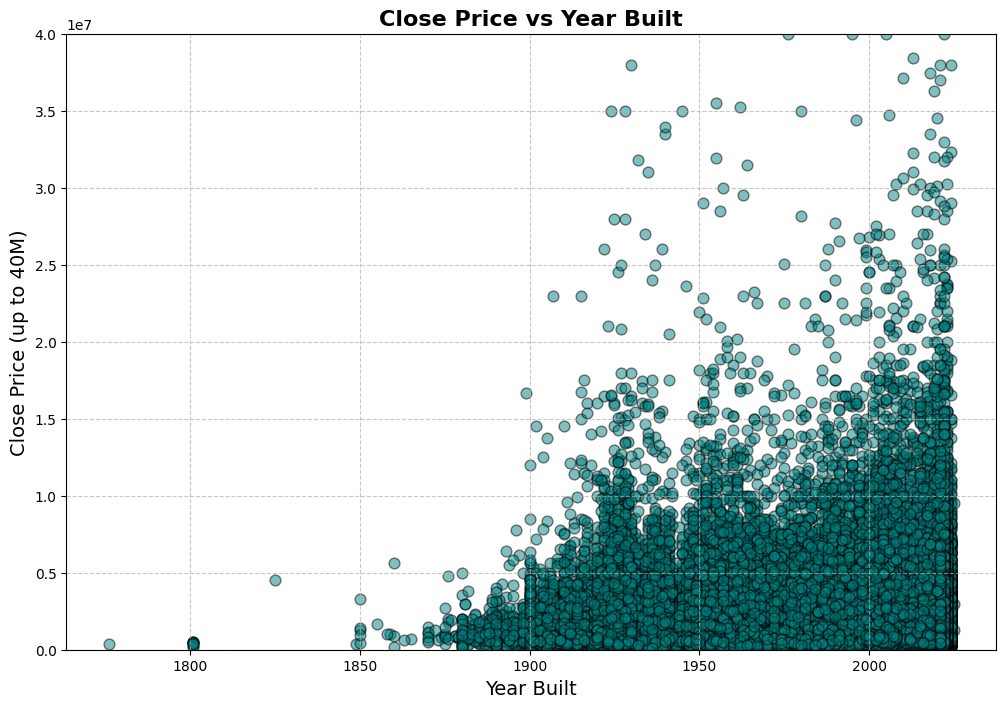

In [ ]:
# Plot a scatter plot of 'YearBuilt' vs 'ClosePrice'
plt.figure(figsize=(12, 8))
plt.scatter(df['YearBuilt'], df['ClosePrice'], alpha=0.5, c='teal', edgecolor='k', s=60)

# Set the y-axis limit to focus on a reasonable range if needed
plt.ylim(0, 4e7)

# Adding titles and labels with refined formatting
plt.title("Close Price vs Year Built", fontsize=16, fontweight='bold')
plt.xlabel("Year Built", fontsize=14)
plt.ylabel("Close Price (up to 40M)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Show tick labels in scientific notation for better readability
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()


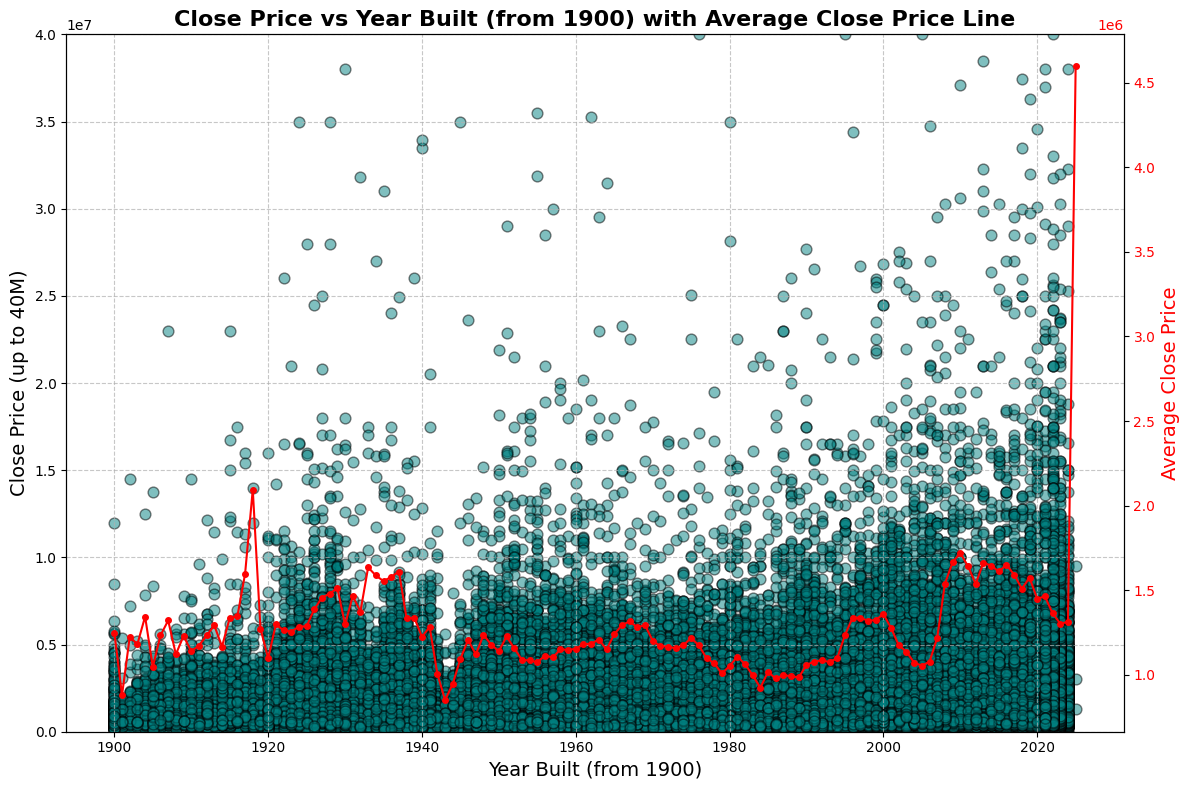

In [ ]:
# Filter the dataframe for properties built from the year 1900 onwards
df_filtered = df[df['YearBuilt'] >= 1900]

# Calculate the average ClosePrice for each year built (from 1900 onwards)
average_price_per_year_filtered = df_filtered.groupby('YearBuilt')['ClosePrice'].mean()

# Plotting the scatter plot with a dual y-axis for the filtered data
fig, ax1 = plt.subplots(figsize=(12, 8))

# Scatter plot of 'YearBuilt' vs 'ClosePrice' for years starting from 1900
ax1.scatter(df_filtered['YearBuilt'], df_filtered['ClosePrice'], alpha=0.5, c='teal', edgecolor='k', s=60)
ax1.set_ylim(0, 4e7)
ax1.set_xlabel("Year Built (from 1900)", fontsize=14)
ax1.set_ylabel("Close Price (up to 40M)", fontsize=14)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.grid(True, linestyle='--', alpha=0.7)

# Creating a secondary y-axis for the average price per year
ax2 = ax1.twinx()
ax2.plot(average_price_per_year_filtered.index, average_price_per_year_filtered.values,
         color='red', marker='o', markersize=4, linestyle='-', label='Average Price per Year Built')
ax2.set_ylabel("Average Close Price", fontsize=14, color="red")
ax2.tick_params(axis='y', labelcolor="red")

# Adding the title and legend
plt.title("Close Price vs Year Built (from 1900) with Average Close Price Line", fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

In [ ]:
# Ensure 'CloseDate' is in datetime format
df['CloseDate'] = pd.to_datetime(df['CloseDate'], errors='coerce')

# Calculate 'BuildingAge' by finding the difference in years between 'CloseDate' and 'YearBuilt'
df['BuildingAge'] = df['CloseDate'].dt.year - df['YearBuilt']


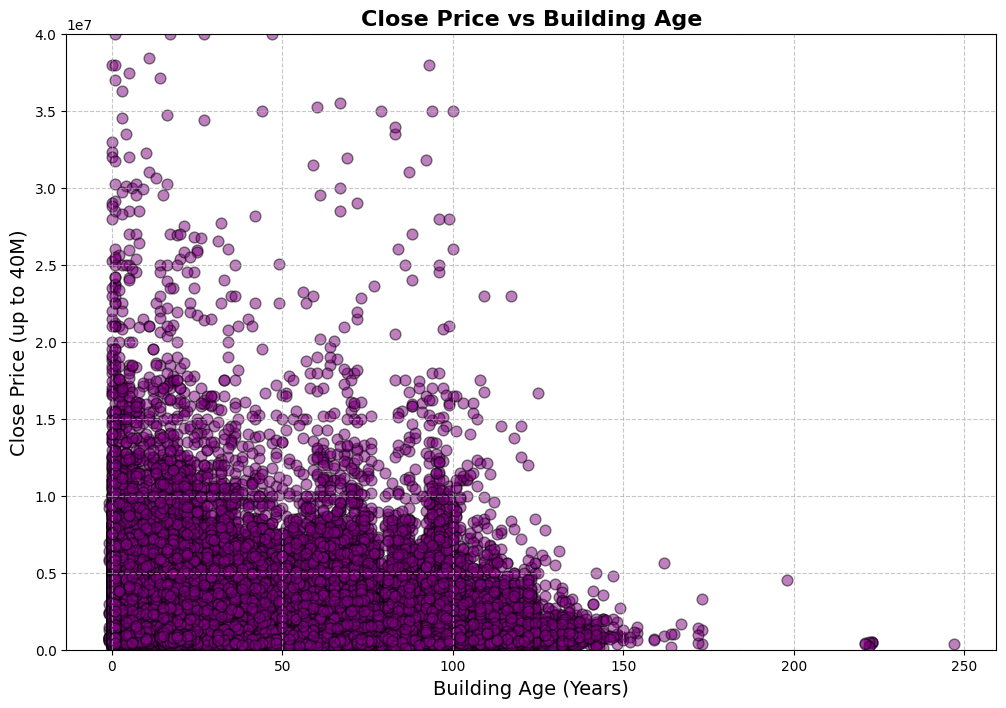

In [ ]:
# Scatter plot of 'BuildingAge' vs 'ClosePrice'
plt.figure(figsize=(12, 8))
plt.scatter(df['BuildingAge'], df['ClosePrice'], alpha=0.5, c='purple', edgecolor='k', s=60)

# Set the y-axis limit to focus on a reasonable range if needed
plt.ylim(0, 4e7)

# Adding titles and labels with refined formatting
plt.title("Close Price vs Building Age", fontsize=16, fontweight='bold')
plt.xlabel("Building Age (Years)", fontsize=14)
plt.ylabel("Close Price (up to 40M)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Show tick labels in scientific notation for better readability
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()


In [ ]:
# for cleaned version
df_clean['CloseDate'] = pd.to_datetime(df_clean['CloseDate'], errors='coerce')
df_clean['BuildingAge'] = df_clean['CloseDate'].dt.year - df_clean['YearBuilt']
#df_clean['BuildingAge'] = df_clean.index.year - df_clean['YearBuilt']


In [ ]:
# display rows where BuildingAge = -1
df_clean[df_clean['BuildingAge'] == -1].head()

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,FireplaceYN,Stories,Levels,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge
5611,34.018073,-118.441759,3130 Mountain View Avenue,Los Angeles,3130.0,Los Angeles,90066.0,Wood,1,0,0,0,4619.0,0,4.0,2023.0,6.0,5.0,NaN,1,1.358446,Unknown,2.295302,1,1.998573,7907.0,2022-12-16,5775000.0,0,3,-1.0
25103,34.001660,-117.587655,2957 South Halton Paseo,San Bernardino,2957.0,Ontario,91761.0,"Carpet,Tile",0,0,0,0,1951.0,1,4.0,2023.0,3.0,3.0,NaN,0,2.000000,Two,3.000000,1,2.000000,2768.0,2022-12-29,650000.0,0,2,-1.0
25758,34.001840,-117.587218,2937 South Halton Paseo,San Bernardino,2937.0,Ontario,91761.0,"Carpet,Tile",1,0,0,0,1951.0,1,2.0,2023.0,3.0,4.0,NaN,0,2.000000,Two,2.000000,1,2.000000,2790.0,2022-11-03,755000.0,0,3,-1.0
30531,33.910513,-118.252650,1927 N Florish Drive,Los Angeles,1927.0,Compton,90222.0,"Carpet, Tile",0,0,0,0,1702.0,1,2.0,2023.0,3.0,3.0,NaN,0,2.000000,Two,0.000000,1,2.000000,2200.0,2022-12-22,708000.0,0,2,-1.0
42114,33.936834,-117.023777,36822 Arietta Way,Riverside,36822.0,Beaumont,92223.0,"Carpet,Vinyl",0,0,0,0,2040.0,1,2.0,2023.0,3.0,4.0,NaN,0,2.000000,Two,1.000000,1,2.000000,5019.0,2022-12-13,536898.0,0,2,-1.0


In [ ]:
df = df.drop(columns=['YearBuilt'])
df_clean = df_clean.drop(columns=['YearBuilt'])

#### Column Distribution

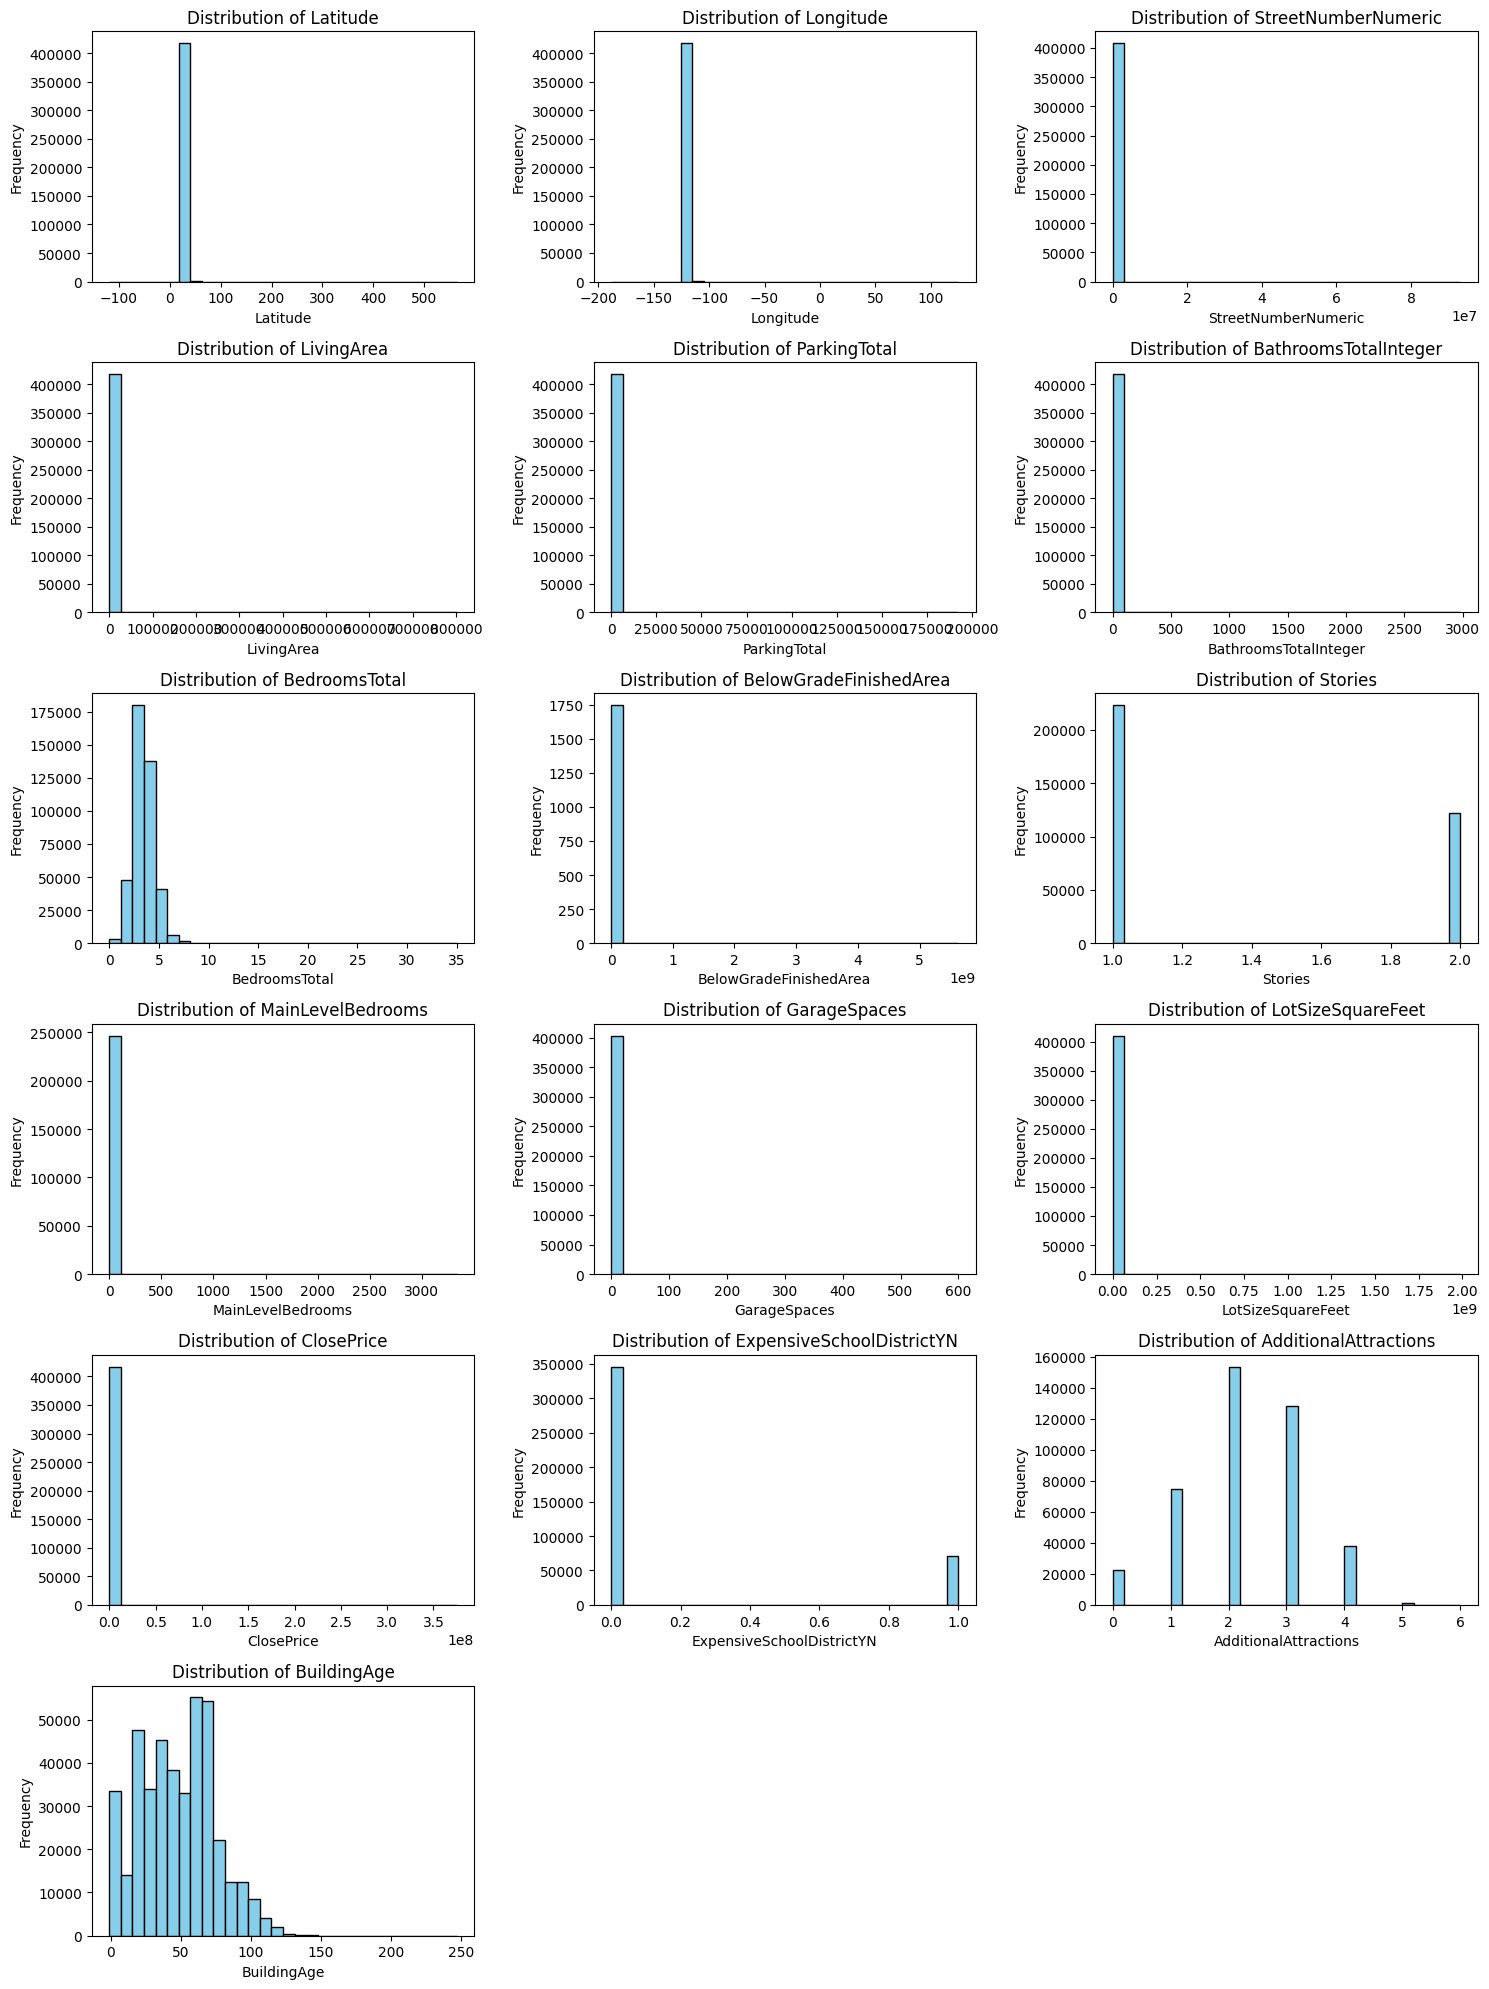

In [ ]:
# Plot distribution for each numeric column in the dataframe
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
#numeric_columns = numeric_columns.drop(['StreetNumberNumeric', 'BuildingAge'])

# Set up the figure with multiple subplots
plt.figure(figsize=(15, 20))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()

plt.show()

probably apply log transformation to ClosePrice

In [ ]:
df.columns

Index(['Latitude', 'Longitude', 'UnparsedAddress', 'CountyOrParish',
       'StreetNumberNumeric', 'City', 'PostalCode', 'Flooring', 'LivingArea',
       'ParkingTotal', 'BathroomsTotalInteger', 'BedroomsTotal',
       'BelowGradeFinishedArea', 'Stories', 'Levels', 'MainLevelBedrooms',
       'GarageSpaces', 'LotSizeSquareFeet', 'CloseDate', 'ClosePrice',
       'ExpensiveSchoolDistrictYN', 'AdditionalAttractions', 'BuildingAge'],
      dtype='object')

#### Unparsed Address Cleaning

In [ ]:
df.head()

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,LivingArea,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,Stories,Levels,MainLevelBedrooms,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge
0,32.659315,-117.096922,2811 C Avenue,San Diego,2811.0,National City,91950,NaN,1974.0,2.0,4.0,4.0,NaN,2.0,Two,NaN,2.0,NaN,2024-01-05,815000.0,0,1,1.0
1,32.659284,-117.097174,2812 C Avenue,San Diego,2812.0,National City,91950,NaN,1974.0,2.0,4.0,4.0,NaN,2.0,Two,NaN,2.0,NaN,2024-01-05,810000.0,0,1,1.0
2,35.277199,-120.646786,2054 Fixlini Street,San Luis Obispo,2054.0,San Luis Obispo,93401,NaN,3736.0,3.0,4.0,4.0,NaN,2.0,Two,3.0,3.0,11219.0,2024-01-02,2100000.0,0,3,5.0
3,39.419080,-123.814842,31451 Bay View Avenue,Mendocino,31451.0,Fort Bragg,95437,Tile,2100.0,2.0,0.0,3.0,NaN,2.0,Two,NaN,2.0,74487.6,2024-01-22,1950000.0,0,3,38.0
4,37.325454,-121.780303,3114 Rasmus Circle,Santa Clara,3114.0,San Jose,95148,"Tile,Wood",2442.0,3.0,3.0,4.0,NaN,NaN,NaN,NaN,3.0,8712.0,2024-01-31,2340000.0,1,3,39.0


In [ ]:
# Removing numbers and the following space
df['UnparsedAddress'] = df['UnparsedAddress'].str.replace(r'^\d+\s', '', regex=True)
df['UnparsedAddress'].head()

,UnparsedAddress
0,C Avenue
1,C Avenue
2,Fixlini Street
3,Bay View Avenue
4,Rasmus Circle


In [ ]:
df_clean['UnparsedAddress'] = df_clean['UnparsedAddress'].str.replace(r'^\d+\s', '', regex=True)
df_clean['UnparsedAddress'].head()

,UnparsedAddress
0,Chinquapin Ave
1,Mecham Drive
2,Miller Avenue
3,Paseo Del Sol
4,Vista Knolls Drive


#### Postal Code Validation

In [ ]:
# Convert PostalCode to numeric, forcing errors to NaN if necessary
df['PostalCode'] = pd.to_numeric(df['PostalCode'], errors='coerce')
df_clean['PostalCode'] = pd.to_numeric(df_clean['PostalCode'], errors='coerce')

df['PostalCode'].describe()

,PostalCode
count,415804.000000
mean,92635.939592
std,1957.494464
min,1010.000000
25%,91784.000000
50%,92404.000000
75%,93534.000000
max,907013.000000


In [ ]:
# exlcude postal code outside the range from 90001 to 96162
df = df[df['PostalCode'].between(90001, 96162)]
df_clean = df_clean[df_clean['PostalCode'].between(90001, 96162)]
print(df.shape)
print(df_clean.shape)

(415774, 23)
(408219, 30)


#### Latitude, Longitude Validation


California Latitude and longitude is 32° 30' N to 42° N and 114° 8' W to 124° 24' W.

In [ ]:
df_clean['Latitude'].describe()

,Latitude
count,407960.000000
mean,34.788624
std,1.981415
min,-119.000000
25%,33.767072
50%,34.098802
75%,35.265644
max,564.000000


In [ ]:
df_clean['Longitude'].describe()

,Longitude
count,407960.000000
mean,-118.678618
std,2.725532
min,-188.543810
25%,-119.753667
50%,-118.033594
75%,-117.259658
max,125.000000


In [ ]:
# Count null values in Longitude and latitude
null_longitude_count = df_clean['Longitude'].isnull().sum()
null_latitude_count = df_clean['Latitude'].isnull().sum()

print(f"Number of null values in 'Longitude': {null_longitude_count}")
print(f"Number of null values in 'Latitude': {null_latitude_count}")

Number of null values in 'Longitude': 259
Number of null values in 'Latitude': 259


In [ ]:
# Filter rows where Latitude is between 32.3 and 42
df_clean = df_clean[(df_clean['Latitude'] >= 32.3) & (df_clean['Latitude'] <= 42)]
df_clean['Latitude'].describe()

,Latitude
count,407913.000000
mean,34.789855
std,1.709061
min,32.544023
25%,33.767171
50%,34.098850
75%,35.265751
max,41.968811


In [ ]:
# Filter rows where longitude is between 114.8 and 124.24
df_clean = df_clean[(df_clean['Longitude'] >= -124.24) & (df_clean['Longitude'] <= -114.8)]
df_clean['Longitude'].describe()

,Longitude
count,407448.000000
mean,-118.704872
std,1.896959
min,-124.219343
25%,-119.763916
50%,-118.035214
75%,-117.260850
max,-115.318301


In [ ]:
df_clean.shape

(407448, 30)

In [ ]:
# Count null values in Longitude and latitude
null_longitude_count = df_clean['Longitude'].isnull().sum()
null_latitude_count = df_clean['Latitude'].isnull().sum()

print(f"Number of null values in 'Longitude': {null_longitude_count}")
print(f"Number of null values in 'Latitude': {null_latitude_count}")

Number of null values in 'Longitude': 0
Number of null values in 'Latitude': 0


#### City Filling and Cleaning



In [ ]:
# Show the full list of unique values in city
unique_cities = sorted(df_clean['City'].unique())
print(unique_cities)

['29 Palms', 'Acampo', 'Acton', 'Adelanto', 'Agoura', 'Agoura Hills', 'Agua Dulce', 'Agua Fria', 'Aguanga', 'Ahwahnee', 'Alabama Hill', 'Alameda', 'Alamo', 'Albany', 'Albion', 'Alhambra', 'Aliso Viejo', 'Alpaugh', 'Alpine', 'Alta Loma', 'Altadena', 'Alturas', 'American Canyon', 'Anaheim', 'Anaheim Hills', 'Anderson', 'Angels Camp', 'Angelus Oaks', 'Antelope', 'Antelope Acres', 'Antioch', 'Anza', 'Apple Valley', 'Aptos', 'Arbuckle', 'Arcadia', 'Arcata', 'Arleta', 'Armona', 'Arnold', 'Aromas', 'Arrowbear', 'Arroyo Grande', 'Artesia', 'Artois', 'Arvin', 'Atascadero', 'Atherton', 'Atwater', 'Atwater Village', 'Auberry', 'Auburn', 'Avalon', 'Avenal', 'Avila Beach', 'Azusa', 'Bakersfield', 'Baldwin Hills', 'Baldwin Lake', 'Baldwin Park', 'Ballico', 'Bangor', 'Banning', 'Barstow', 'Bass Lake', 'Bassett', 'Bay Point', 'Bear Valley', 'Bear Valley Springs', 'Beaumont', 'Beckwourth', 'Bel Air', 'Bell', 'Bell Canyon', 'Bell Gardens', 'Bellflower', 'Belmont', 'Belvedere', 'Ben Lomond', 'Benicia', '

In [ ]:
# Show the rows where city includes ()
# Filter rows where 'City' column contains '('
rows_with_parentheses = df_clean[df_clean['City'].str.contains(r'\(', na=False)]

# Display the rows
rows_with_parentheses

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,FireplaceYN,Stories,Levels,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge
569,34.249718,-118.456171,Lassen Street,Los Angeles,14854.0,Mission Hills (San Fernando),91345.0,"Carpet, Tile",0,0,0,0,2530.0,0,2.0,4.0,5.0,NaN,1,1.000000,One,5.000000,0,2.000000,1.743900e+04,2022-01-06,1200000.0,0,1,75.0
1675,34.257958,-118.461367,Blackhawk Street,Los Angeles,15114.0,Mission Hills (San Fernando),91345.0,"Carpet, Tile",1,0,0,1,1300.0,1,2.0,2.0,3.0,NaN,0,1.000000,One,4.000000,0,2.000000,7.516000e+03,2022-01-13,670000.0,0,3,69.0
3072,34.257581,-118.463406,Devonshire Street,Los Angeles,15209.0,Mission Hills (San Fernando),91345.0,"Carpet, Tile",0,0,0,0,1893.0,0,0.0,2.0,4.0,NaN,0,1.000000,One,4.000000,0,0.000000,7.801000e+03,2022-02-03,570000.0,0,0,68.0
3279,37.968288,-121.644252,Delta Rd,Contra Costa,2813.0,Brentwood (CC),94513.0,"Carpet,Wood",0,0,0,0,1887.0,1,2.0,2.0,3.0,NaN,1,1.000000,One,2.295302,0,2.000000,8.929800e+04,2022-01-14,1020000.0,0,2,47.0
3510,37.081334,-122.085488,Highway 9,Santa Cruz,8705.0,Outside Area (Inside Ca),95005.0,Wood,0,0,0,1,2296.0,0,2.0,NaN,15.0,NaN,1,1.358446,Unknown,2.295302,0,2.000000,2.578750e+05,2022-02-11,3425000.0,1,2,61.0
3627,37.963664,-121.232792,S Carroll,Other County,213.0,Outside Area (Inside Ca),95215.0,"Carpet, Tile",1,0,0,0,1288.0,1,1.0,2.0,3.0,NaN,0,1.000000,One,3.000000,0,1.000000,4.788000e+03,2022-02-01,325000.0,0,2,75.0
3842,37.911001,-121.729529,Ogden,Contra Costa,1886.0,Brentwood (CC),94513.0,"Carpet,Concrete,Laminate,Tile",0,0,0,0,2665.0,1,3.0,3.0,2.0,NaN,1,1.000000,One,2.295302,0,3.000000,1.031000e+04,2022-03-31,839000.0,0,2,21.0
4353,34.262440,-118.454756,Woodman Avenue,Los Angeles,10558.0,Mission Hills (San Fernando),91345.0,"Carpet, Tile",0,0,0,0,1714.0,1,2.0,3.0,3.0,NaN,1,1.000000,"One,Two,MultiSplit",0.000000,0,2.000000,5.479000e+03,2022-01-31,742000.0,0,2,56.0
5169,34.250286,-118.463882,Lassen Street,Los Angeles,15223.0,Mission Hills (San Fernando),91345.0,"Carpet, Tile",0,0,0,0,1898.0,0,0.0,3.0,3.0,NaN,1,1.000000,One,1.000000,0,0.000000,7.197000e+03,2022-03-15,778000.0,0,1,65.0
5543,38.988044,-121.026023,Fawn Lane,Placer,1190.0,Outside Area (Inside Ca),95722.0,"Carpet, Tile",0,0,0,0,2124.0,1,2.0,2.0,3.0,NaN,1,1.000000,One,1.000000,0,2.000000,1.045440e+05,2022-12-30,635000.0,1,2,44.0


In [ ]:
unique_cities = sorted(rows_with_parentheses['City'].unique())
print(unique_cities)

['Brentwood (CC)', 'El Cerrito (CC)', 'Mission Hills (San Diego)', 'Mission Hills (San Fernando)', 'North Park (San Diego)', 'Ocean Beach (San Diego)', 'Outside Area (Inside Ca)', 'Pacific Beach (San Diego)', 'Rancho Bernardo (San Diego)']


In [ ]:
# show rows where city includes 'Brentwood' in df_clean
df_clean[df_clean['City'].str.contains('Brentwood', na=False)]

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,FireplaceYN,Stories,Levels,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge
1324,34.058860,-118.467075,Terryhill Place,Los Angeles,11615.0,Brentwood,90049.0,Stone,0,0,0,0,4079.0,1,2.0,5.0,4.0,NaN,1,2.000000,Two,2.000000,0,2.0,7.361000e+03,2022-02-01,3750000.0,0,2,75.0
3279,37.968288,-121.644252,Delta Rd,Contra Costa,2813.0,Brentwood (CC),94513.0,"Carpet,Wood",0,0,0,0,1887.0,1,2.0,2.0,3.0,NaN,1,1.000000,One,2.295302,0,2.0,8.929800e+04,2022-01-14,1020000.0,0,2,47.0
3842,37.911001,-121.729529,Ogden,Contra Costa,1886.0,Brentwood (CC),94513.0,"Carpet,Concrete,Laminate,Tile",0,0,0,0,2665.0,1,3.0,3.0,2.0,NaN,1,1.000000,One,2.295302,0,3.0,1.031000e+04,2022-03-31,839000.0,0,2,21.0
6318,37.917972,-121.728159,Grenadier Way,Contra Costa,391.0,Brentwood,94513.0,"Carpet,Tile,Wood",1,0,0,0,2665.0,1,3.0,3.0,2.0,NaN,1,1.000000,One,2.295302,0,3.0,7.750000e+03,2022-12-29,769000.0,0,3,23.0
6478,37.920302,-121.688549,Shiles Loop,Contra Costa,3085.0,Brentwood,94513.0,"Carpet,Laminate,Vinyl",0,0,0,0,1706.0,1,2.0,2.0,3.0,NaN,1,1.000000,One,2.295302,0,2.0,6.100000e+03,2022-12-29,625000.0,0,2,27.0
6496,37.926685,-121.728038,Gala Ln,Contra Costa,31.0,Brentwood,94513.0,"Carpet,Tile",0,0,0,0,1524.0,1,2.0,2.0,2.0,NaN,1,1.000000,One,2.295302,0,2.0,7.140000e+03,2022-12-23,595000.0,0,2,26.0
6583,37.934580,-121.750102,Presidio Dr,Contra Costa,2692.0,Brentwood,94513.0,"Carpet,Tile,Wood",1,0,0,0,2908.0,1,2.0,3.0,5.0,NaN,1,2.000000,Two,2.295302,0,2.0,7.763000e+03,2022-12-02,905000.0,0,3,19.0
6958,37.912014,-121.723887,Bismarck Ln,Contra Costa,1424.0,Brentwood,94513.0,Carpet,0,0,0,0,1900.0,1,2.0,2.0,2.0,NaN,1,1.000000,One,2.295302,0,2.0,1.080000e+04,2022-11-22,650000.0,0,2,22.0
6969,37.905296,-121.717864,Hagan Ln,Contra Costa,1339.0,Brentwood,94513.0,Wood,0,0,0,0,1582.0,1,2.0,2.0,2.0,NaN,1,1.000000,One,2.295302,0,2.0,6.090000e+03,2022-12-07,650000.0,0,2,19.0
6973,37.945770,-121.732808,Las Colinas Dr,Contra Costa,1931.0,Brentwood,94513.0,"Carpet, Tile",0,0,0,0,1801.0,1,2.0,2.0,3.0,NaN,1,1.000000,One,2.295302,0,2.0,6.342000e+03,2022-11-23,705000.0,0,2,18.0


* Caution: Cities in different counties might have the same name

In [ ]:
# Remove parentheses, content inside, and the space before the parentheses
df_clean['City'] = df_clean['City'].str.replace(r'\s*\(.*?\)', '', regex=True)

# Show the rows where city includes ()
# Filter rows where 'City' column contains '('
rows_with_parentheses = df_clean[df_clean['City'].str.contains(r'\(', na=False)]

# Display the rows
rows_with_parentheses

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,FireplaceYN,Stories,Levels,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,CloseDate,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge


In [ ]:
# count rows where city == 'Missing'
missing_city_count = df_clean[df_clean['City'] == 'Missing'].shape[0]
print(f"Number of rows with 'Missing' city: {missing_city_count}")

Number of rows with 'Missing' city: 2094


In [ ]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

# Initialize geolocator
geolocator = Nominatim(user_agent="Filling (jiayin_tu@berkeley.edu)")

# Function to fetch city name using latitude and longitude
def fetch_city_from_coords(row):
    if row['City'] == "Missing":  # Only fetch for rows where City is "Missing"
        try:
            if not pd.isna(row['Latitude']) and not pd.isna(row['Longitude']):
                location = geolocator.reverse((row['Latitude'], row['Longitude']), timeout=10)
                time.sleep(1)  # Pause for 1 second between requests
                if location:
                    return location.raw.get('address', {}).get('city', None)
        except GeocoderTimedOut:
            return "Missing"  # Return "Missing" if geocoder times out
        except Exception as e:
            print(f"Error for coordinates ({row['Latitude']}, {row['Longitude']}): {e}")
            return "Missing"
    return row['City']  # Return original City if not "Missing"

# Apply the reverse geocoding function
df_clean['City'] = df_clean.apply(fetch_city_from_coords, axis=1)

In [ ]:
# count rows where city == 'Missing'
missing_city_count = df_clean[df_clean['City'] == 'Missing'].shape[0]
print(f"Number of rows with 'Missing' city: {missing_city_count}")

Number of rows with 'Missing' city: 0


In [ ]:
print(df_clean.shape)

(407448, 30)


In [ ]:
# Display rows where geocoding failed
failed_geocoding = df_clean[df_clean['City'].isna()]
print("Sample rows where geocoding failed:")
print(failed_geocoding.head())
print(failed_geocoding.shape)

Sample rows where geocoding failed:
       Latitude   Longitude     UnparsedAddress  CountyOrParish  \
76    34.135610 -116.054294              Zircon  San Bernardino   
87    38.665170 -121.368410      Liberty Street      Sacramento   
281   36.859084 -121.647555                 NaN        Monterey   
1045  37.110105 -122.089613                 NaN      Santa Cruz   
1080  36.887671 -121.634490                 NaN      San Benito   

      StreetNumberNumeric  City  PostalCode          Flooring  ViewYN  \
76                    0.0  None     92277.0          Concrete       1   
87                 5411.0  None     95660.0            Carpet       1   
281                   NaN  None     95004.0  Carpet,Tile,Wood       1   
1045                  NaN  None     95005.0     Laminate,Tile       1   
1080                  NaN  None     95004.0       Carpet,Tile       1   

      WaterfrontYN  BasementYN  PoolPrivateYN  LivingArea  AttachedGarageYN  \
76               0           0             

In [ ]:
# Drop rows with missing values in City
df_clean.dropna(subset=['City'], inplace=True)
print(df_clean.shape)

(405950, 30)


#### Seasonality or Trend Investigation

<ipython-input-154-7f35851fe43a>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close_price = df_clean['ClosePrice'].resample('M').mean()


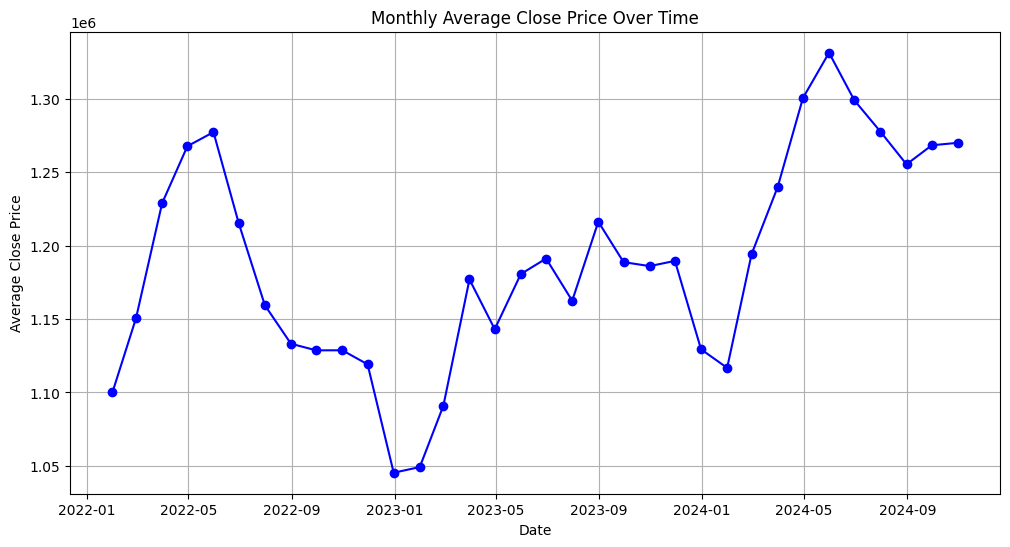

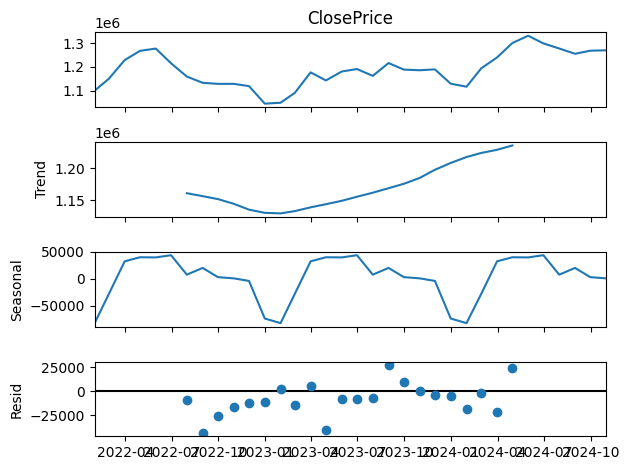

In [ ]:
# Ensure CloseDate is in datetime format and set it as the index
df_clean['CloseDate'] = pd.to_datetime(df_clean['CloseDate'])
df_clean.set_index('CloseDate', inplace=True)

# Resample ClosePrice data by month and compute the mean price
monthly_close_price = df_clean['ClosePrice'].resample('M').mean()

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(monthly_close_price, marker='o', color='b', linestyle='-')
plt.title("Monthly Average Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Close Price")
plt.grid(True)
plt.show()


from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series to observe trend, seasonality, and residuals
decomposition = seasonal_decompose(monthly_close_price.dropna(), model='additive')
decomposition.plot()
plt.show()

- Trend: The close price has a shifting trend over time, which we could analyze further to understand underlying factors (e.g., market conditions, economic shifts).
- Seasonality: There is some seasonality in close prices, which means prices might be higher or lower during certain periods consistently.
- Residuals: Any patterns in the residuals may indicate additional underlying factors affecting the close price that are not captured by this decomposition.

#### Flooring Investigation

In [ ]:
missing_flooring_count = df_clean['Flooring'].isnull().sum()
print(f"Number of missing values in 'Flooring' column: {missing_flooring_count}")


Number of missing values in 'Flooring' column: 0


In [ ]:
df_clean['Flooring'].value_counts()

,count
Flooring,
"Carpet, Tile",60349
Wood,45384
"Carpet,Tile",31925
Laminate,27782
"Tile,Wood",21576
Tile,17944
"Carpet,Tile,Wood",17327
Carpet,13734
"Carpet,Wood",12955


In [ ]:
flooring_unique_count = df_clean['Flooring'].nunique()
print(f"Number of unique values in 'Flooring' column: {flooring_unique_count}")

Number of unique values in 'Flooring' column: 552


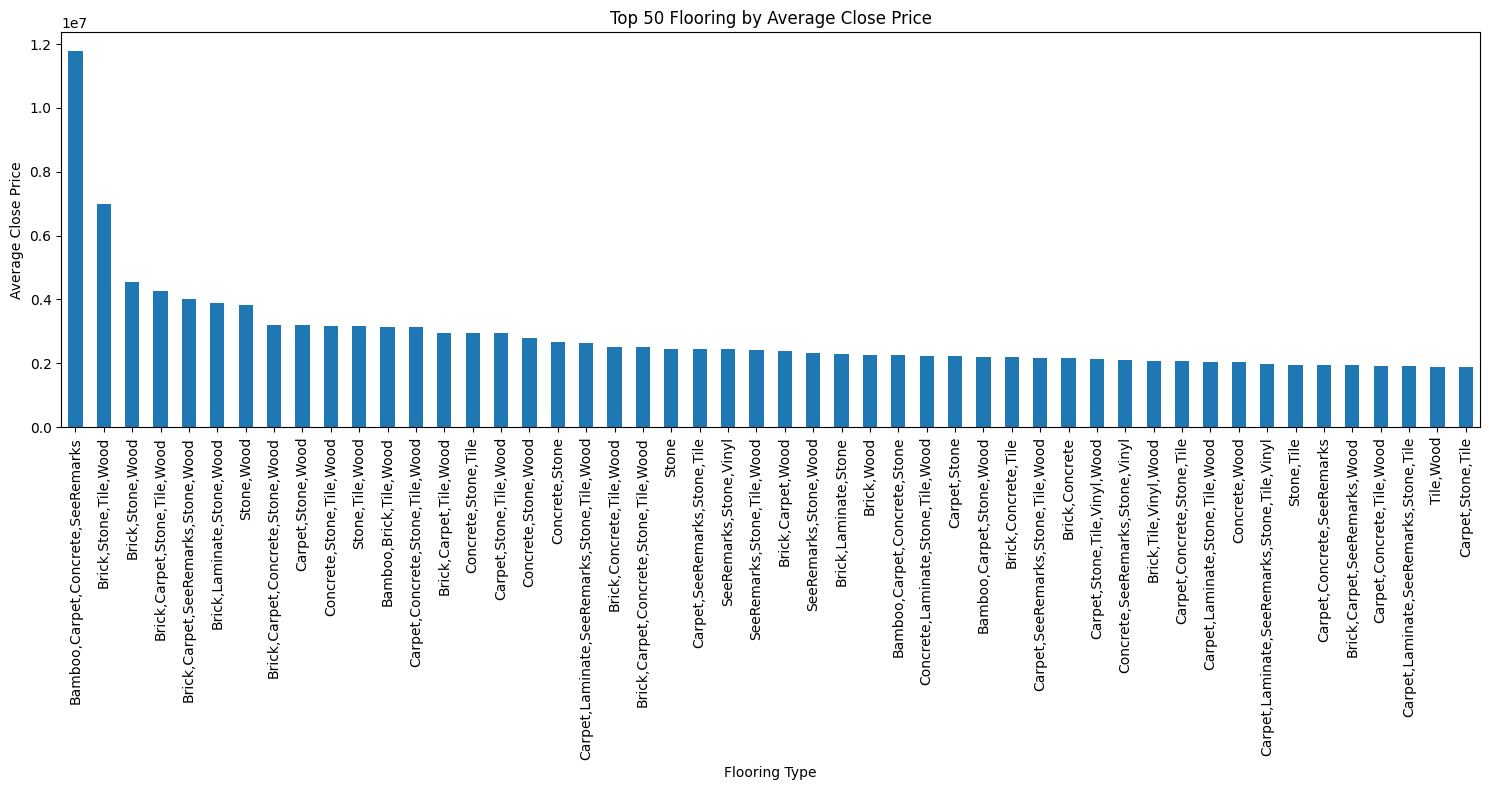

In [ ]:
# Group by 'Flooring' and calculate the average 'ClosePrice' for each flooring type
top_50_flooring = (
    df.groupby('Flooring')['ClosePrice']
    .mean()
    .sort_values(ascending=False)
    .head(50)
)

# Plotting the top 50 flooring types with the highest average ClosePrice
plt.figure(figsize=(15, 8))
top_50_flooring.plot(kind='bar', fontsize=10)
plt.title("Top 50 Flooring by Average Close Price")
plt.xlabel("Flooring Type")
plt.ylabel("Average Close Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Export Final Dataset
#df_clean.to_csv('/content/gdrive/MyDrive/ColabNotebooks/IDX Exchange/Cleaned CRMLS Datasets/Cleaned_Combined_Data4.csv', index=True)

In [ ]:
df_clean.head()

,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,PostalCode,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,LivingArea,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,BedroomsTotal,BelowGradeFinishedArea,FireplaceYN,Stories,Levels,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet,ClosePrice,ExpensiveSchoolDistrictYN,AdditionalAttractions,BuildingAge
CloseDate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-04,33.147270,-117.340604,Chinquapin Ave,San Diego,295.0,Carlsbad,92008.0,"Carpet, Tile, Wood",1,0,0,0,2645.0,1,2.0,4.0,4.0,NaN,0,1.358446,ThreeOrMore,0.000000,0,2.0,13376.0,2499999.0,1,2,6.0
2022-01-10,34.235979,-117.202269,Mecham Drive,San Bernardino,944.0,Lake Arrowhead,92352.0,"Carpet, Tile",1,0,0,0,2070.0,1,1.0,3.0,3.0,NaN,1,1.358446,ThreeOrMore,0.000000,0,1.0,3397.0,640000.0,0,3,15.0
2022-03-23,34.114130,-117.442493,Miller Avenue,San Bernardino,16596.0,Fontana,92336.0,"Carpet, Tile",0,0,0,0,1174.0,1,2.0,2.0,3.0,NaN,0,1.000000,One,3.000000,0,2.0,9900.0,438000.0,0,1,62.0
2022-01-10,33.783767,-116.447280,Paseo Del Sol,Riverside,36353.0,Cathedral City,92234.0,"Carpet,Tile",1,0,0,1,1996.0,0,4.0,2.0,2.0,NaN,1,1.358446,Unknown,2.295302,0,2.0,6098.0,615000.0,0,3,17.0
2022-01-19,39.767729,-121.586400,Vista Knolls Drive,Butte,6091.0,Paradise,95969.0,"Carpet, Tile",1,0,0,0,1422.0,1,2.0,2.0,3.0,NaN,0,1.000000,One,3.000000,1,2.0,12197.0,399990.0,0,3,1.0


In [ ]:
# Count missing values in each column
missing_values = df_clean.isnull().sum()

# Display the count of missing values for each column
print(missing_values)

Latitude                          0
Longitude                         0
UnparsedAddress                9293
CountyOrParish                    0
StreetNumberNumeric            9386
City                              0
PostalCode                        0
Flooring                          0
ViewYN                            0
WaterfrontYN                      0
BasementYN                        0
PoolPrivateYN                     0
LivingArea                        0
AttachedGarageYN                  0
ParkingTotal                      0
BathroomsTotalInteger           129
BedroomsTotal                     0
BelowGradeFinishedArea       404241
FireplaceYN                       0
Stories                           0
Levels                            0
MainLevelBedrooms             45307
NewConstructionYN                 0
GarageSpaces                   4177
LotSizeSquareFeet              7277
ClosePrice                        0
ExpensiveSchoolDistrictYN         0
AdditionalAttractions       

## Check Correlation between features and label

In [ ]:
numerical_df = df1.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix.corr().abs(), annot=True, cmap='coolwarm')

# Add titles and labels
plt.title('Correlation Heatmap of Numerical Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

# Display the correlation matrix as a formatted table
print("Correlation Matrix:")
print(tabulate(correlation_matrix, headers='keys', tablefmt='psql'))


# Property-related exploration


In [ ]:
df1_property = df1[[ 'CloseDate','ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress', 'CountyOrParish', 'StreetNumberNumeric', 'City', 'StateOrProvince', 'PostalCode', 'ElementarySchool', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchool', 'HighSchool', 'HighSchoolDistrict', 'MiddleOrJuniorSchoolDistrict','ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'PropertyType', 'LivingArea', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount','AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'BelowGradeFinishedArea','CoveredSpaces','FireplaceYN', 'Stories', 'Levels', 'LotSizeDimensions', 'LotSizeArea','MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'LotSizeSquareFeet']]
df1_property


,Latitude,Longitude,UnparsedAddress,CountyOrParish,StreetNumberNumeric,City,StateOrProvince,PostalCode,ElementarySchool,ElementarySchoolDistrict,...,CoveredSpaces,FireplaceYN,Stories,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,LotSizeSquareFeet
0,32.659315,-117.096922,2811 C Avenue,San Diego,2811.0,National City,CA,91950,NaN,NaN,...,NaN,False,2.0,Two,NaN,NaN,NaN,False,2.0,NaN
1,32.659284,-117.097174,2812 C Avenue,San Diego,2812.0,National City,CA,91950,NaN,NaN,...,NaN,False,2.0,Two,NaN,NaN,NaN,False,2.0,NaN
2,35.277199,-120.646786,2054 Fixlini Street,San Luis Obispo,2054.0,San Luis Obispo,CA,93401,NaN,NaN,...,NaN,True,2.0,Two,NaN,1.121900e+04,3.0,False,3.0,11219.0
3,39.419080,-123.814842,31451 Bay View Avenue,Mendocino,31451.0,Fort Bragg,CA,95437,NaN,NaN,...,NaN,True,2.0,Two,NaN,1.710000e+00,NaN,NaN,2.0,74487.6
4,37.325454,-121.780303,3114 Rasmus Circle,Santa Clara,3114.0,San Jose,CA,95148,Other,NaN,...,NaN,True,NaN,NaN,NaN,8.712000e+03,NaN,False,3.0,8712.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105356,33.789262,-116.516226,2550 S Araby Drive,Riverside,2550.0,Palm Springs,CA,92264,NaN,NaN,...,NaN,True,NaN,NaN,NaN,1.960200e+04,NaN,False,1.0,19602.0
105357,34.043069,-118.360909,1714 S Marvin Avenue,Los Angeles,1714.0,Los Angeles,CA,90019,NaN,NaN,...,NaN,True,NaN,MultiSplit,NaN,6.662000e+03,NaN,False,NaN,6662.0
105358,39.777447,-121.957633,5515 Market Street,Butte,5515.0,Chico,CA,95973,NaN,NaN,...,NaN,True,1.0,One,NaN,2.831400e+04,4.0,False,0.0,28314.0
105359,34.486558,-120.092440,13800 HWY 101,Santa Barbara,13800.0,Goleta,CA,93117,NaN,NaN,...,NaN,NaN,1.0,One,NaN,1.350360e+08,NaN,False,3.0,135036000.0


AttributeError: This method only works with the ScalarFormatter

Error in callback <function _draw_all_if_interactive at 0x7b5c6d822830> (for post_execute):


KeyboardInterrupt: 

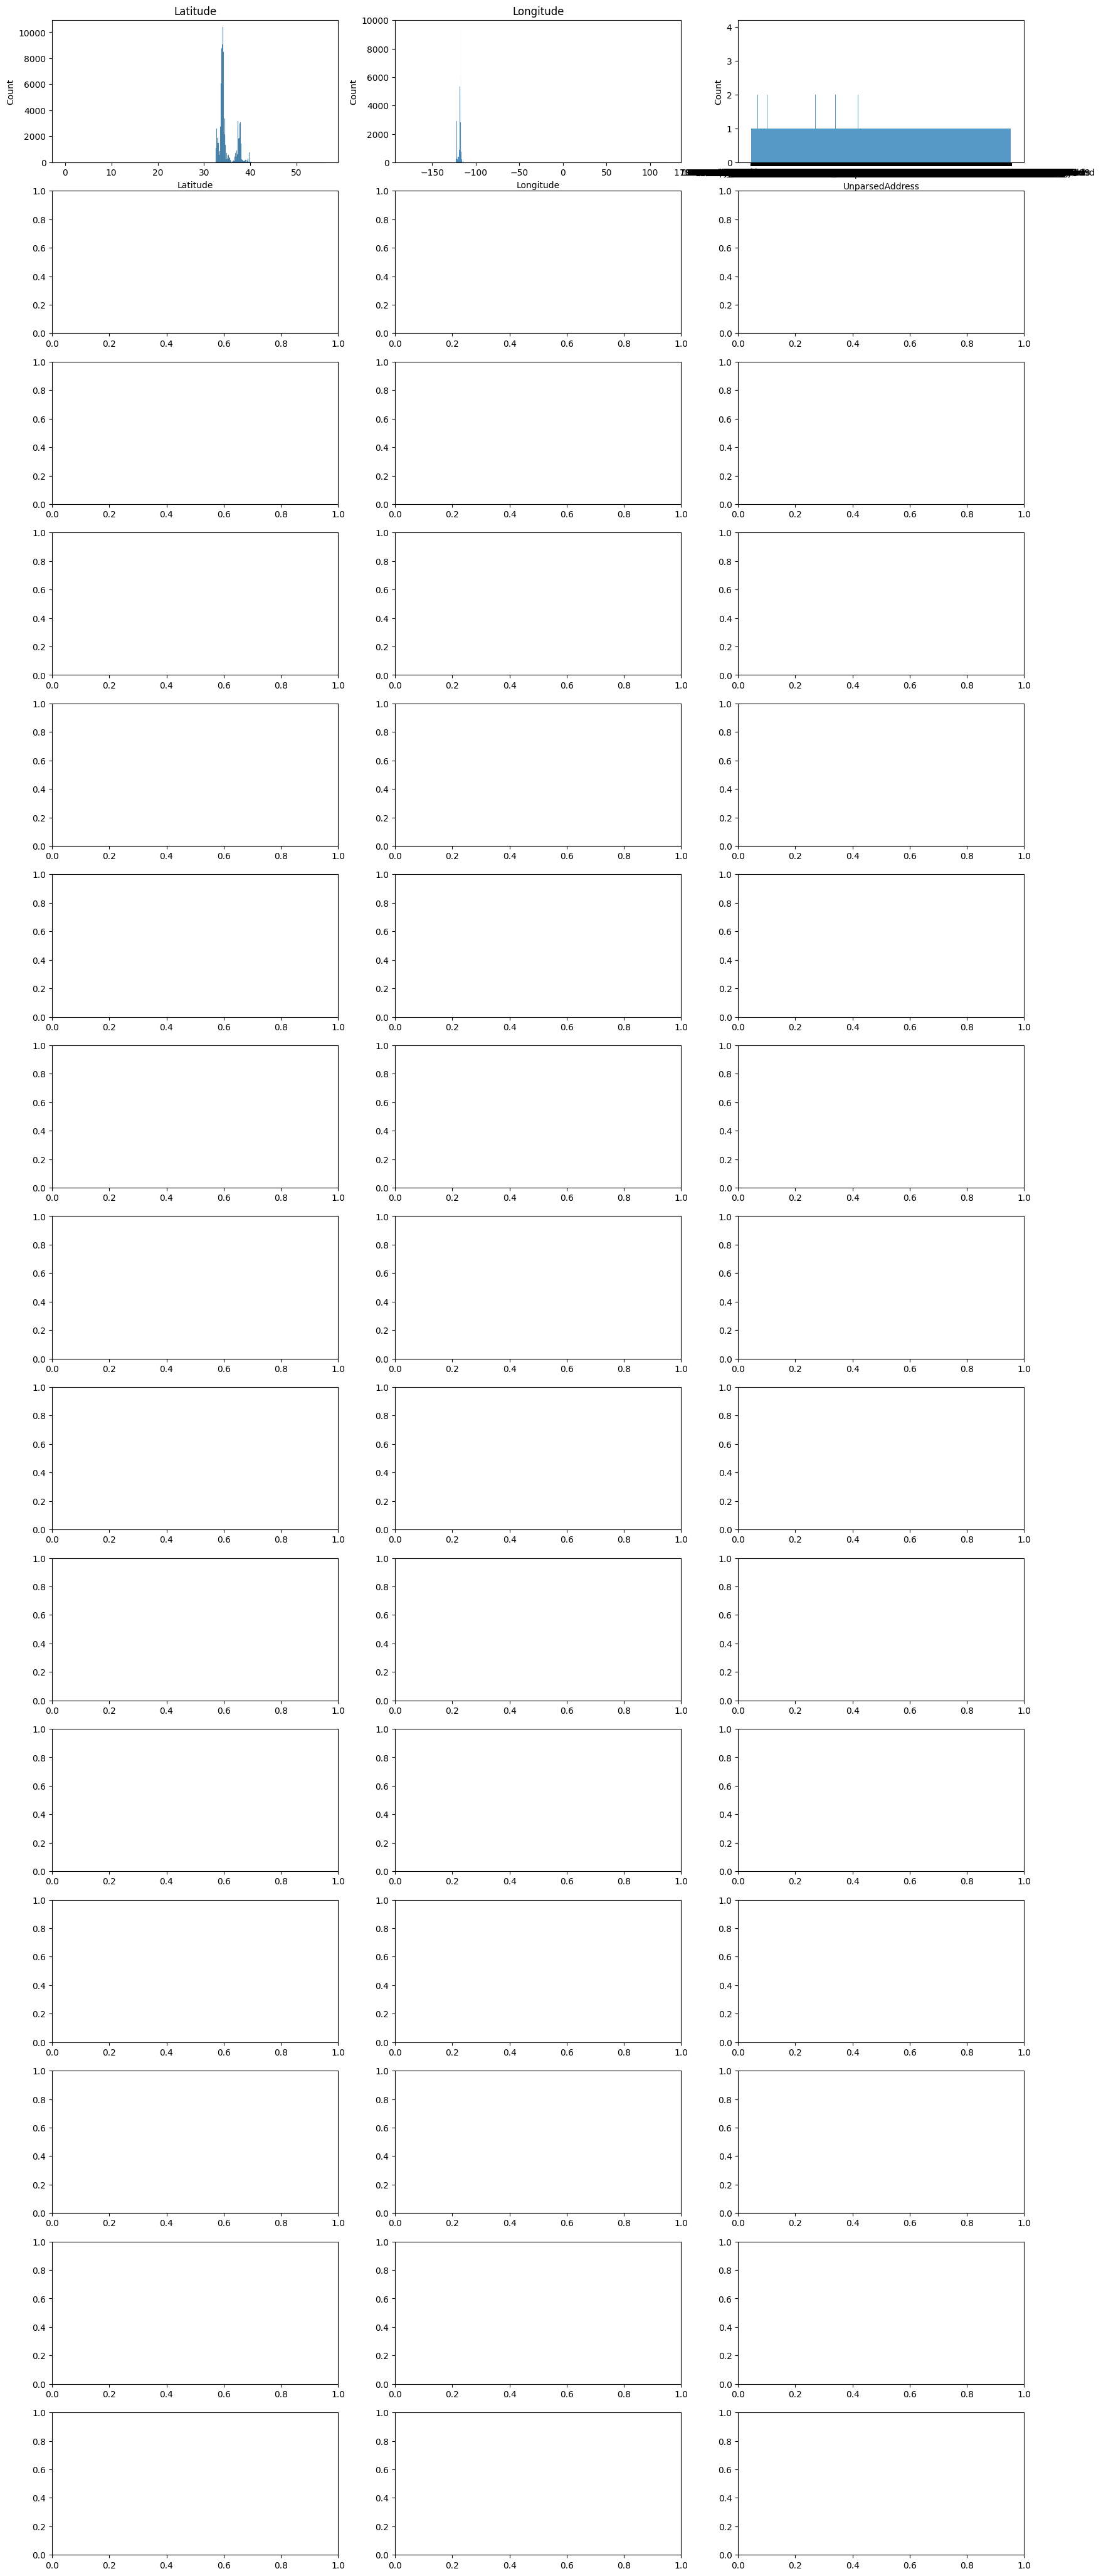

In [ ]:
numeric_sold_1_property = df1_property.select_dtypes(include=['number'])

fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(20, 10))
index = 0
axs = axs.flatten()

for k, v in numeric_sold_1_property.items():
    sns.histplot(v, ax=axs[index])
    axs[index].ticklabel_format(style='plain', axis='x')
    axs[index].set_title(k)
    index += 1

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [ ]:
for k, v in df1_property.items():
  if pd.api.types.is_numeric_dtype(v) and not pd.api.types.is_bool_dtype(v):
    q1=v.quantile(.25)
    q3=v.quantile(.75)
    iqr=q3-q1
    v_col=v[(v<=q1-1.5*iqr)|(v>=q3+1.5*iqr)]
    perc=np.shape(v_col)[0]*100.0/np.shape(df1_property)[0]
    print("Column %s outliers = %.2f%%"%(k,perc))

Column Latitude outliers = 0.06%
Column Longitude outliers = 0.02%
Column StreetNumberNumeric outliers = 7.94%
Column ElementarySchoolDistrict outliers = 0.00%
Column MiddleOrJuniorSchoolDistrict outliers = 0.00%
Column LivingArea outliers = 4.18%
Column FireplacesTotal outliers = 0.00%
Column AboveGradeFinishedArea outliers = 0.00%
Column TaxAnnualAmount outliers = 0.00%
Column ParkingTotal outliers = 16.05%
Column LotSizeAcres outliers = 13.29%
Column YearBuilt outliers = 0.10%
Column BathroomsTotalInteger outliers = 5.63%
Column TaxYear outliers = 0.00%
Column BuildingAreaTotal outliers = 0.34%
Column BedroomsTotal outliers = 2.77%
Column BelowGradeFinishedArea outliers = 0.51%
Column CoveredSpaces outliers = 0.00%
Column Stories outliers = 0.00%
Column LotSizeArea outliers = 12.12%
Column MainLevelBedrooms outliers = 0.26%
Column GarageSpaces outliers = 96.57%
Column LotSizeSquareFeet outliers = 13.30%


In [ ]:
numerical_df = df1_property.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix.corr().abs(), annot=False, cmap='coolwarm')

# Add titles and labels
plt.title('Correlation Heatmap of Numerical Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()


correlations = correlation_matrix.unstack().reset_index()
correlations.columns = ['Feature1', 'Feature2', 'Correlation']

# Filter out self-correlations (where Feature1 == Feature2) and correlations with an absolute value of 1
correlations = correlations[(correlations['Feature1'] != correlations['Feature2']) & (correlations['Correlation'] != 1)]
correlations['Abs_Correlation'] = correlations['Correlation'].abs()

# Sort by absolute correlation value in descending order
sorted_correlations = correlations.sort_values(by='Abs_Correlation', ascending=False).drop(columns=['Abs_Correlation'])

# Display the sorted list of correlations
print("Correlations from strongest to weakest:")
print(tabulate(sorted_correlations, headers='keys', tablefmt='psql'))



### Model Training

Linear Regression (Anna)

Random Forest (Jenny)

Gradient Boossting (Jenny)

Decision Tree (Euro)

RNN (Esther)

Feature Importance:
